In [1]:
import random 
from pathlib import Path
import warnings 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter,sosfiltfilt,savgol_filter,find_peaks
warnings.filterwarnings("ignore")
SEED=42
random.seed(SEED)
np.random.seed(SEED)
sns.set_style("whitegrid")

In [2]:
FS=125 
WINDOW_SECONDS=8 
WINDOW_SIZE=WINDOW_SECONDS*FS
STEP_SECONDS=4 
STEP_SIZE=STEP_SECONDS*FS
PATIENT_IDS=[1,2,3,4,5]



In [3]:
FS = 125                 # PPG sampling frequency
WINDOW_SECONDS = 8       # Each PPG sample/window is 8 seconds
WINDOW_SIZE = FS * WINDOW_SECONDS
STEP_SECONDS = 4
STEP_SIZE = FS * STEP_SECONDS

# Small classroom demo: first 5 patient records
PATIENT_IDS = [1, 2, 3, 4, 5]

BASE_URL = (
    "https://physionet.org/files/bidmc/1.0.0/bidmc_csv"
)

print("Sampling frequency:", FS, "Hz")
print("Window size:", WINDOW_SECONDS, "seconds")
print("Samples per window:", WINDOW_SIZE)

Sampling frequency: 125 Hz
Window size: 8 seconds
Samples per window: 1000


In [4]:
def load_patient(patient_id):
    """
    Load a single patient record from the BIDMC dataset.
    """
    cache_dir = Path('bidmc_cache')
    signal_path = cache_dir / f"bidmc_{patient_id:02d}_Signals.csv"
    numeric_path = cache_dir / f"bidmc_{patient_id:02d}_Numerics.csv"
    if signal_path.exists() and numeric_path.exists():
        signals = pd.read_csv(signal_path)
        numerics = pd.read_csv(numeric_path)
    else:
        signal_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Signals.csv"
        numeric_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Numerics.csv"
        signals = pd.read_csv(signal_url)
        numerics = pd.read_csv(numeric_url)
    signals.columns=signals.columns.str.strip()
    numerics.columns=numerics.columns.str.strip()
    return signals, numerics
all_patient_data=[]
for patient_id in PATIENT_IDS:
    signals, numerics = load_patient(patient_id)
    all_patient_data.append({
        "patient_id": patient_id,
        "signals": signals,
        "numerics": numerics,
    })
    print(f"Loaded patient {patient_id}: {signals.shape[0]} samples, {numerics.shape[0]} numeric records")

Loaded patient 1: 60001 samples, 481 numeric records
Loaded patient 2: 60001 samples, 481 numeric records


Loaded patient 3: 60001 samples, 481 numeric records


Loaded patient 4: 60001 samples, 481 numeric records
Loaded patient 5: 60001 samples, 481 numeric records


In [5]:
example_signals=all_patient_data[1]['signals']
example_numerics=all_patient_data[1]['numerics']

print(example_signals.columns.tolist())
print(example_numerics.columns.tolist())
print(example_signals.head())
print(example_numerics.head())

['Time [s]', 'II', 'PLETH', 'RESP', 'V', 'AVR']
['Time [s]', 'HR', 'PULSE', 'RESP', 'SpO2']
   Time [s]       II    PLETH     RESP        V      AVR
0     0.000  0.14453  0.63636  0.04059  0.83529  0.74414
1     0.008  0.15625  0.65689  0.04059  0.83529  0.74023
2     0.016  0.15625  0.67351  0.04059  0.84118  0.74023
3     0.024  0.16016  0.68817  0.04059  0.84510  0.73438
4     0.032  0.16016  0.69990  0.04059  0.84510  0.73438
   Time [s]  HR  PULSE  RESP  SpO2
0         0  93     92    16   100
1         1  93     93    16   100
2         2  93     93    16   100
3         3  94     94    16   100
4         4  94     94    16   100


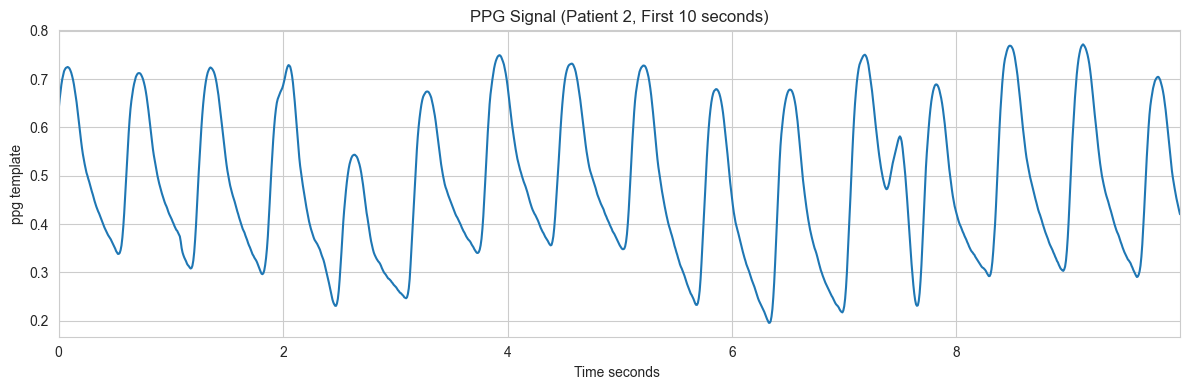

In [6]:
duration=10 
number_of_samples=duration*FS
time=example_signals['Time [s]'][:number_of_samples]
ppg=example_signals['PLETH'][:number_of_samples]

plt.figure(figsize=(12,4))
plt.plot(time,ppg)
plt.title("PPG Signal (Patient 2, First 10 seconds)")
plt.xlabel('Time seconds ')
plt.ylabel('ppg template')
plt.xlim(time.iloc[0],time.iloc[-1])
plt.tight_layout()
plt.show()

In [7]:
ACTIONS={
    0:"Raw Signal",
    1:"Moving Average",
    2:"Savitzky-Golay",
    3:"Butterworth Bandpass"
}

N_ACTIONS=len(ACTIONS)
for action_id,action_name in ACTIONS.items():
    print(f"{action_id}: {action_name}")

0: Raw Signal
1: Moving Average
2: Savitzky-Golay
3: Butterworth Bandpass


In [8]:
def moving_average_filter(signal, window=7):
    kernel = np.ones(window) / window

    filtered = np.convolve(
        signal,
        kernel,
        mode="same"
    )

    return filtered


def savgol_ppg_filter(signal):
    """
    Smooth the signal while preserving the shape of PPG peaks.
    """
    return savgol_filter(
        signal,
        window_length=21,
        polyorder=3
    )


def butterworth_filter(signal, fs=125):
    """
    PPG heart-rate frequency range:
    approximately 0.5 to 5 Hz.
    """

    sos = butter(
        N=4,
        Wn=[0.5, 5.0],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    return sosfiltfilt(sos, signal)


def apply_action(signal, action):
    """
    Apply the filter selected by the RL agent.
    """

    if action == 0:
        return signal.copy()

    elif action == 1:
        return moving_average_filter(signal)

    elif action == 2:
        return savgol_ppg_filter(signal)

    elif action == 3:
        return butterworth_filter(signal, FS)

    else:
        raise ValueError("Invalid action")

In [9]:
def estimate_heart_rate(signal,fs=125):
    signal=np.array(signal,dtype=float)
    normalized_signal=(signal-np.mean(signal))/(np.std(signal)+1e-8)
    
    minimum_distance=int(0.5*fs)
    peaks,_=find_peaks(normalized_signal,distance=minimum_distance,prominence=0.35)
    if len(peaks)<2:
        return np.nan,peaks 
    
    peak_intervals=np.diff(peaks)/fs
    median_interval=np.median(peak_intervals)
    estimated_hr=60/median_interval
    
    
    if  estimated_hr <35 or estimated_hr > 220 : 
        return np.nan ,peaks 
    
    return estimated_hr,peaks 
    

In [10]:
def calculate_noise_score(signal):
    smooth_signal=savgol_filter(signal,window_length=31,polyorder=3)
    high_frequency_part=signal-smooth_signal
    score=(np.std(high_frequency_part)/np.std(signal)+1e-8)
    
    return score

create ppg windows 

In [11]:
def create_window_dataset(all_patient_data):
    rows=[]
    
    for patient_data in all_patient_data:
        patient_id=patient_data['patient_id']
        signals=patient_data['signals'].copy()
        numerics=patient_data['numerics'].copy()
        
        signal_time=pd.to_numeric(signals['Time [s]'],errors='coerce').to_numpy()
        
        ppg_signal=pd.to_numeric(signals['PLETH'],errors='coerce').interpolate().bfill().ffill().to_numpy()
        
        numeric_time=pd.to_numeric(numerics['Time [s]'],errors='coerce').to_numpy()
        
        reference_pulse=pd.to_numeric(numerics['PULSE'],errors='coerce').to_numpy()
        for start in range(0,len(ppg_signal)-WINDOW_SIZE+1,STEP_SIZE):
            end=start+WINDOW_SIZE
            window_ppg=ppg_signal[start:end]
            window_time=signal_time[start:end]
            
            start_time=signal_time[start]
            end_time=signal_time[end-1]
            
            mask=(numeric_time>=start_time)&(numeric_time<=end_time)
            
            pulse_values=reference_pulse[mask]
            pulse_values=pulse_values[np.isfinite(pulse_values)]
            
            if len(pulse_values)==0:
                continue
            
            reference_hr=np.median(pulse_values)
            
            if not 35 <= reference_hr <= 220:
                continue
            
            noise_score=calculate_noise_score(window_ppg)
            rows.append({
                "patient_id":patient_id,
                "start_time":start_time,
                "end_time":end_time,
                "mid_time":window_time[WINDOW_SIZE//2],
                "ppg_signal":window_ppg,
                "reference_hr":reference_hr,
                "noise_score":noise_score
            })
    return pd.DataFrame(rows) 



window_df=create_window_dataset(all_patient_data)
print(len(window_df)) 
display(window_df.drop(columns=['ppg_signal']).head(10))      

593


,patient_id,start_time,end_time,mid_time,reference_hr,noise_score
0,1,0.0,7.992,4.0,93.0,0.121155
1,1,4.0,11.992,8.0,94.0,0.123468
2,1,8.0,15.992,12.0,94.0,0.120951
3,1,12.0,19.992,16.0,94.0,0.119533
4,1,16.0,23.992,20.0,94.0,0.123212
5,1,20.0,27.992,24.0,94.0,0.126791
6,1,24.0,31.992,28.0,94.0,0.128007
7,1,28.0,35.992,32.0,94.0,0.130413
8,1,32.0,39.992,36.0,94.0,0.133665
9,1,36.0,43.992,40.0,94.0,0.134126


In [12]:
STATE_NAMES={
    0:"Low Noise",
    1:"Medium Noise",
    2:"High Noise"} 


q1=window_df["noise_score"].quantile(0.33)
q2=window_df['noise_score'].quantile(0.66)

def noise_to_state(noise_score):
    if noise_score <= q1 : 
        return 0 
    
    elif noise_score <= q2 :
        return 1 
    else : 
        return 2 
    
window_df['state'] =window_df['noise_score'].apply(noise_to_state)

window_df['state_name']=window_df['state'].map(STATE_NAMES)
print("First threshold:",round(q1,4))
print("Second threshold:",round(q2,4))

print(window_df['state_name'].value_counts())

First threshold: 0.0711
Second threshold: 0.0944
state_name
High Noise      202
Low Noise       196
Medium Noise    195
Name: count, dtype: int64


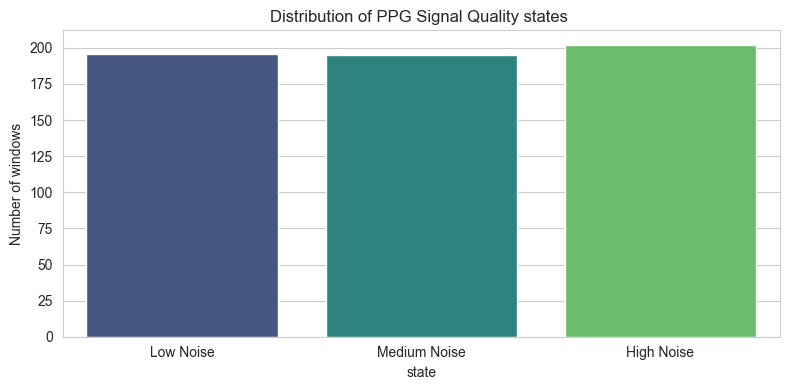

In [13]:
plt.figure(figsize=(8,4))
sns.countplot(data=window_df,x='state_name',order=['Low Noise','Medium Noise','High Noise'],palette='viridis')
plt.title("Distribution of PPG Signal Quality states ")
plt.xlabel('state')
plt.ylabel('Number of windows')
plt.tight_layout()
plt.show()

In [14]:
def calculate_reward(ppg_window,action,reference_hr):
    filtered_signal=apply_action(ppg_window,action)
    estimated_hr,peaks=estimate_heart_rate(filtered_signal,FS)
    
    if np.isnan(estimated_hr):
        return -50.0 ,np.nan
    error=abs(estimated_hr-reference_hr)
    
    error=min(error,50)
    reward =-error 
    return reward ,estimated_hr 

Precomputed error 

In [15]:
reward_matrix=np.zeros((len(window_df),N_ACTIONS))

estimated_hr_matrix=np.zeros((len(window_df),N_ACTIONS))
for row_position,(_,row) in enumerate(window_df.iterrows()):
    ppg_window=row['ppg_signal']
    reference_hr=row['reference_hr']
    
    for action in range(N_ACTIONS):
        reward,estimated_hr=calculate_reward(ppg_window,action,reference_hr)
        reward_matrix[row_position,action]=reward
        estimated_hr_matrix[row_position,action]=estimated_hr
        
print(reward_matrix.shape)
print(estimated_hr_matrix.shape)

for action in range(N_ACTIONS):
    print(f"Action {action} ({ACTIONS[action]}): Mean Reward = {reward_matrix[:,action].mean():.2f}, Mean Estimated HR = {np.nanmean(estimated_hr_matrix[:,action]):.2f}")

(593, 4)
(593, 4)
Action 0 (Raw Signal): Mean Reward = -1.52, Mean Estimated HR = 89.64
Action 1 (Moving Average): Mean Reward = -1.54, Mean Estimated HR = 89.74
Action 2 (Savitzky-Golay): Mean Reward = -1.57, Mean Estimated HR = 89.68
Action 3 (Butterworth Bandpass): Mean Reward = -1.41, Mean Estimated HR = 89.34


In [16]:
TRAIN_PATIENTS=[1,2,3,4]
TEST_PATIENTS=[5]
train_mask=window_df['patient_id'].isin(TRAIN_PATIENTS).to_numpy()
test_mask=window_df['patient_id'].isin(TEST_PATIENTS).to_numpy()

test_indices=np.where(test_mask)[0]
train_indices=np.where(train_mask)[0]

print(len(train_indices))
print(len(test_indices))
print(TRAIN_PATIENTS)
print(TEST_PATIENTS)

474
119
[1, 2, 3, 4]
[5]


Observe noise state
        ↓
Select filter using ε-greedy
        ↓
Estimate heart rate
        ↓
Receive reward
        ↓
Episode ends

In [17]:
N_STATES=3 
N_ACTIONS=2

Q=np.zeros((N_STATES, N_ACTIONS))
visit_count=np.zeros((N_STATES, N_ACTIONS),dtype=int) 
epsilon=1.0 
epsilon_min=0.05 
epsilon_decay=0.98
number_of_epochs=150

reward_history=[]
epsilon_history=[]

print("Initial Q-table:")
print(Q)


Initial Q-table:
[[0. 0.]
 [0. 0.]
 [0. 0.]]


In [18]:
def epsilon_greedy_action(state,Q,epsilon):
    if np.random.random() < epsilon:
        action = np.random.randint(N_ACTIONS)
        decision='Exploration'
        
    else:
        maximum_q =np.max(Q[state])
        
        best_actions=np.flatnonzero(Q[state]==maximum_q)
        
        
        action=np.random.choice(best_actions)
        decision='Exploitation'
    return action, decision

epsilon greedy channel

In [19]:
# Initialize the agent and training parameters
N_STATES = 3
N_ACTIONS = 2
number_of_epochs = 150

Q = np.zeros((N_STATES, N_ACTIONS))
visit_count = np.zeros((N_STATES, N_ACTIONS), dtype=int)
reward_history = []
epsilon_history = []

epsilon = 1.0       # Initial probability of choosing a random action
epsilon_min = 0.05  # Keep at least 5% exploration
epsilon_decay = 0.98

if len(train_indices) == 0:
    raise ValueError("No training samples found. Check TRAIN_PATIENTS and patient_id values.")

for epoch in range(number_of_epochs):
    shuffled_indices = np.random.permutation(train_indices)
    epoch_rewards = []
    exploration_count = 0
    exploitation_count = 0
    
    for data_index in shuffled_indices:
        state = int(window_df.iloc[data_index]['state'])
        action, decision = epsilon_greedy_action(state, Q, epsilon)
        if decision == 'Exploration':
            exploration_count += 1
        else:
            exploitation_count += 1
            
            
        reward = reward_matrix[data_index, action]
        G = reward
        visit_count[state, action] += 1
        learning_rate = 1 / visit_count[state, action]
        
        
        Q[state, action] += learning_rate * (G - Q[state, action])
        
        epoch_rewards.append(reward)
    average_reward = np.mean(epoch_rewards)
    reward_history.append(average_reward)
    epsilon_history.append(epsilon)
    
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{number_of_epochs}: Average Reward = {average_reward:.2f}, Epsilon = {epsilon:.4f}, Exploration = {exploration_count}, Exploitation = {exploitation_count}")
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
        

Epoch 1/150: Average Reward = -1.45, Epsilon = 1.0000, Exploration = 474, Exploitation = 0
Epoch 5/150: Average Reward = -1.43, Epsilon = 0.9224, Exploration = 443, Exploitation = 31
Epoch 10/150: Average Reward = -1.48, Epsilon = 0.8337, Exploration = 386, Exploitation = 88
Epoch 15/150: Average Reward = -1.45, Epsilon = 0.7536, Exploration = 361, Exploitation = 113
Epoch 20/150: Average Reward = -1.42, Epsilon = 0.6812, Exploration = 332, Exploitation = 142
Epoch 25/150: Average Reward = -1.44, Epsilon = 0.6158, Exploration = 287, Exploitation = 187
Epoch 30/150: Average Reward = -1.44, Epsilon = 0.5566, Exploration = 280, Exploitation = 194
Epoch 35/150: Average Reward = -1.46, Epsilon = 0.5031, Exploration = 237, Exploitation = 237
Epoch 40/150: Average Reward = -1.43, Epsilon = 0.4548, Exploration = 212, Exploitation = 262
Epoch 45/150: Average Reward = -1.44, Epsilon = 0.4111, Exploration = 193, Exploitation = 281
Epoch 50/150: Average Reward = -1.43, Epsilon = 0.3716, Exploratio

Epoch 105/150: Average Reward = -1.46, Epsilon = 0.1223, Exploration = 58, Exploitation = 416

Epoch 110/150: Average Reward = -1.44, Epsilon = 0.1106, Exploration = 52, Exploitation = 422
Epoch 115/150: Average Reward = -1.44, Epsilon = 0.0999, Exploration = 52, Exploitation = 422
Epoch 120/150: Average Reward = -1.43, Epsilon = 0.0903, Exploration = 43, Exploitation = 431
Epoch 125/150: Average Reward = -1.43, Epsilon = 0.0817, Exploration = 35, Exploitation = 439
Epoch 130/150: Average Reward = -1.43, Epsilon = 0.0738, Exploration = 32, Exploitation = 442
Epoch 135/150: Average Reward = -1.43, Epsilon = 0.0667, Exploration = 34, Exploitation = 440
Epoch 140/150: Average Reward = -1.44, Epsilon = 0.0603, Exploration = 37, Exploitation = 437
Epoch 145/150: Average Reward = -1.43, Epsilon = 0.0545, Exploration = 32, Exploitation = 442
Epoch 150/150: Average Reward = -1.44, Epsilon = 0.0500, Exploration = 21, Exploitation = 453


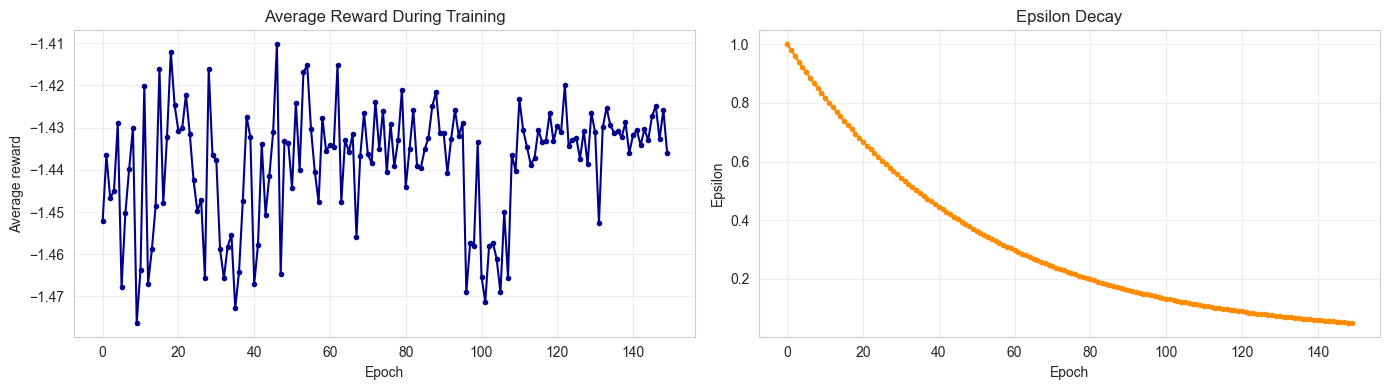

In [20]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4)
)

axes[0].plot(
    reward_history,
    color="darkblue",
    marker="o",
    markersize=3
)

axes[0].set_title(
    "Average Reward During Training"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average reward")
axes[0].grid(alpha=0.3)

axes[1].plot(
    epsilon_history,
    color="darkorange",
    marker="o",
    markersize=3
)

axes[1].set_title(
    "Epsilon Decay"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Epsilon")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
q_table = pd.DataFrame(
    Q,
    index=[
        STATE_NAMES[state]
        for state in range(N_STATES)
    ],
    columns=[
        ACTIONS[action]
        for action in range(N_ACTIONS)
    ]
)

print("Learned Q-table:")
display(q_table.round(3))

Learned Q-table:


,Raw Signal,Moving Average
Low Noise,-2.702,-2.767
Medium Noise,-1.574,-1.631
High Noise,-0.766,-0.757


In [22]:
learned_policy=np.argmax(Q,axis=1)
policy_rows=[]

for state in range(Q.shape[0]):
    best_action=learned_policy[state]
    policy_rows.append({
        'State':STATE_NAMES[state],
        'Selected_action':ACTIONS[best_action],
        'Estimated reward':Q[state,best_action],
        'Estimated HR error':-Q[state,best_action]
    })

policy_df=pd.DataFrame(policy_rows)
display(policy_df.round(3))

,State,Selected_action,Estimated reward,Estimated HR error
0,Low Noise,Raw Signal,-2.702,2.702
1,Medium Noise,Raw Signal,-1.574,1.574
2,High Noise,Moving Average,-0.757,0.757


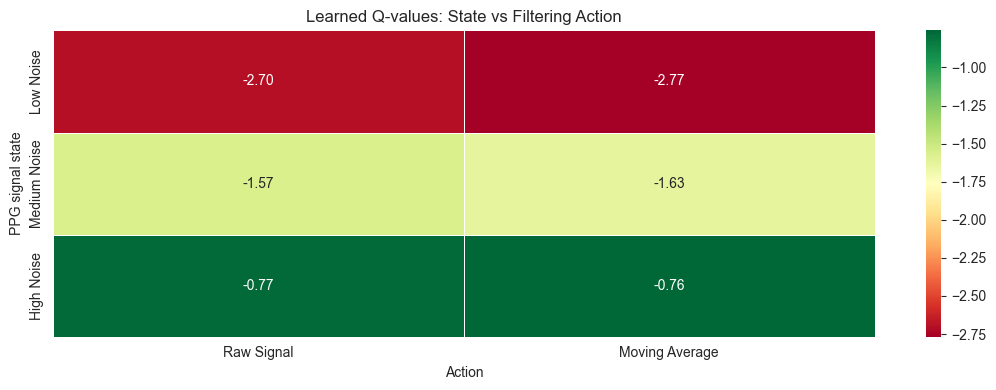

In [23]:
plt.figure(figsize=(11, 4))

sns.heatmap(
    q_table,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title(
    "Learned Q-values: State vs Filtering Action"
)
plt.xlabel("Action")
plt.ylabel("PPG signal state")
plt.tight_layout()
plt.show()


In [24]:
def evaluate_policy(indices,policy):
    errors = []
    predictions=[]
    references=[]
    selected_actions=[]
    
    for data_index in indices:
        row=window_df.iloc[data_index]
        state=int(row['state'])
        action=int(policy[state])
        estimated_hr=estimated_hr_matrix[data_index,action]
        reference_hr=row['reference_hr']
        if np.isnan(estimated_hr):
            error=50.0 
        else : 
            error=abs(estimated_hr-reference_hr)
            
        errors.append(error)
        predictions.append(estimated_hr)
        references.append(reference_hr)
        selected_actions.append(ACTIONS[action])

    return {
        'MAE':np.mean(errors),
        'errors':np.array(errors),
        'predictions':np.array(predictions),
        'references':np.array(references),
        'actions':selected_actions
    }

mc_result=evaluate_policy(test_indices,learned_policy)
print('MC e-greedy test MAE:',round(mc_result['MAE'],2),'BPM')

MC e-greedy test MAE: 1.87 BPM


In [25]:

comparison_rows=[]
learned_policy=np.argmax(Q,axis=1)
mc_result=evaluate_policy(test_indices,learned_policy)

for action in range(N_ACTIONS):
    fixed_policy=np.full(N_STATES,action)
    result=evaluate_policy(test_indices,fixed_policy)
    comparison_rows.append({
        'Policy':f"Fixed Action {action} ({ACTIONS[action]})",
        'MAE (BPM)':result['MAE']
    })
    
comparison_rows.append({
    'Policy':'MC epsilon-greedy',
    'MAE (BPM)':mc_result['MAE']
})

comparison_df=pd.DataFrame(comparison_rows).sort_values("MAE (BPM)")
display(comparison_df.round(3))

,Policy,MAE (BPM)
1,Fixed Action 1 (Moving Average),1.862
2,MC epsilon-greedy,1.871
0,Fixed Action 0 (Raw Signal),1.875


In [26]:
display(comparison_df.round(6))

,Policy,MAE (BPM)
1,Fixed Action 1 (Moving Average),1.862097
2,MC epsilon-greedy,1.871492
0,Fixed Action 0 (Raw Signal),1.874723


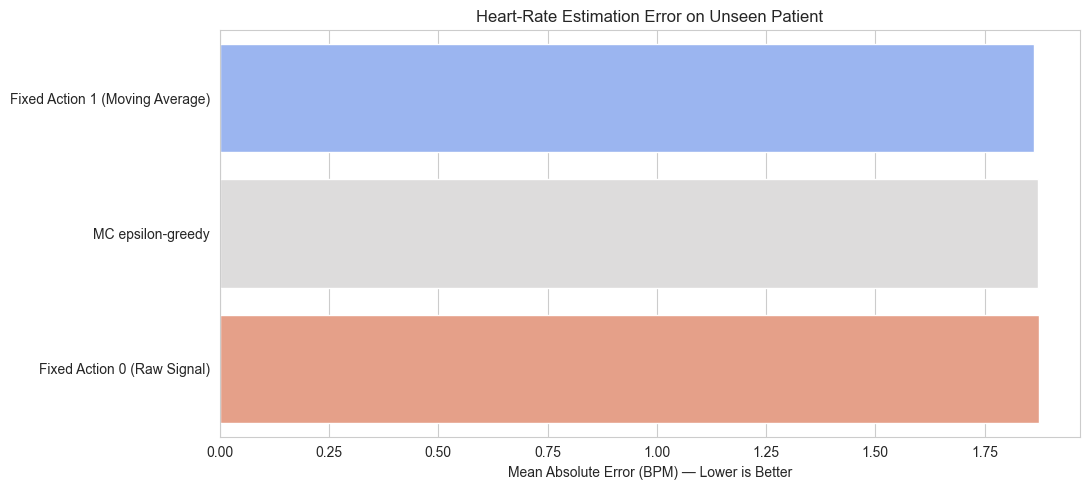

In [27]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=comparison_df,
    x="MAE (BPM)",
    y="Policy",
    hue="Policy",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Heart-Rate Estimation Error on Unseen Patient"
)
plt.xlabel("Mean Absolute Error (BPM) — Lower is Better")
plt.ylabel("")
plt.tight_layout()
plt.show()

visual example 

In [28]:
# Select a high-noise test window
high_noise_test_indices = [
    index
    for index in test_indices
    if window_df.iloc[index]["state"] == 2
]

if len(high_noise_test_indices) > 0:
    example_index = high_noise_test_indices[0]
else:
    example_index = test_indices[0]

example_row = window_df.iloc[example_index]

example_state = int(example_row["state"])
example_action = int(
    learned_policy[example_state]
)

raw_ppg = example_row["ppg_signal"]

filtered_ppg = apply_action(
    raw_ppg,
    example_action
)

raw_hr, raw_peaks = estimate_heart_rate(
    raw_ppg,
    FS
)

filtered_hr, filtered_peaks = estimate_heart_rate(
    filtered_ppg,
    FS
)

reference_hr = example_row["reference_hr"]

window_time = (
    np.arange(len(raw_ppg)) / FS
)

print("Patient:", example_row["patient_id"])
print("State:", STATE_NAMES[example_state])
print("Agent selected:", ACTIONS[example_action])
print("Reference HR:", round(reference_hr, 2), "BPM")
print("Raw estimated HR:", round(raw_hr, 2), "BPM")
print(
    "Filtered estimated HR:",
    round(filtered_hr, 2),
    "BPM"
)

Patient: 5
State: High Noise
Agent selected: Moving Average
Reference HR: 98.0 BPM
Raw estimated HR: 98.68 BPM
Filtered estimated HR: 98.68 BPM


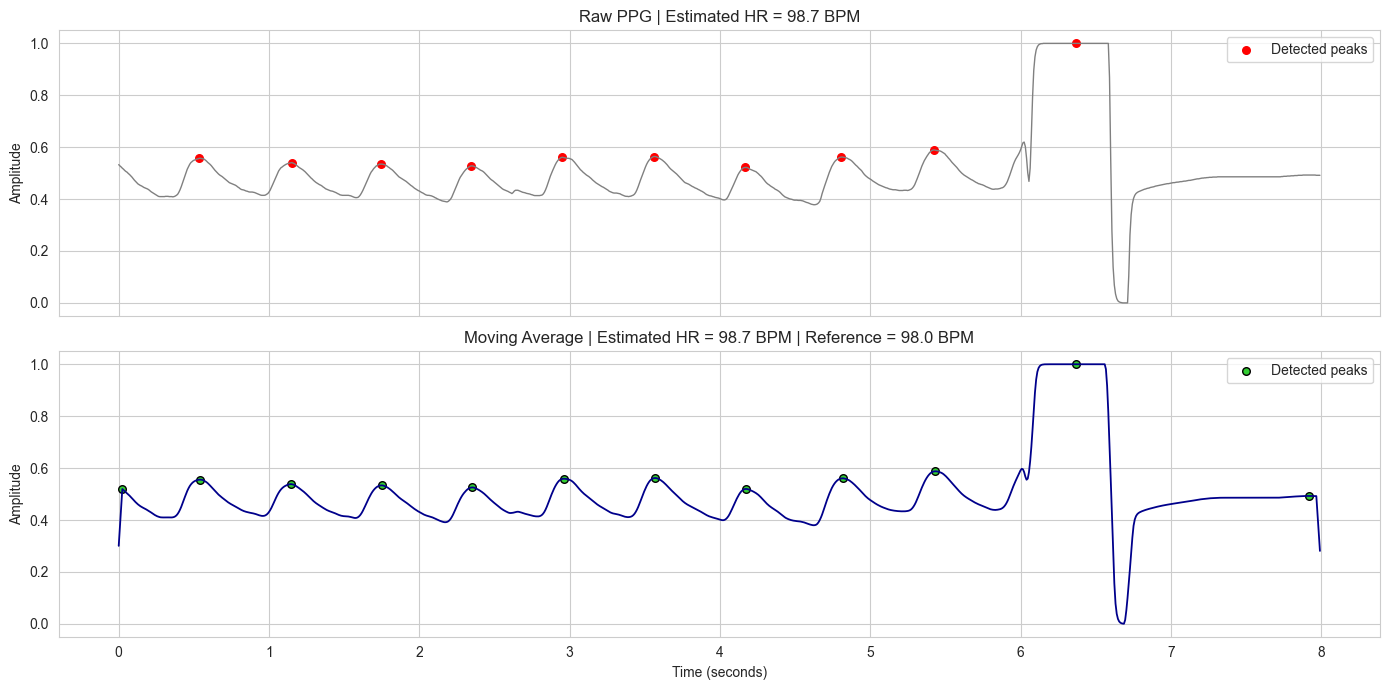

In [29]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True
)

axes[0].plot(
    window_time,
    raw_ppg,
    color="gray",
    linewidth=1
)

axes[0].scatter(
    window_time[raw_peaks],
    raw_ppg[raw_peaks],
    color="red",
    s=30,
    label="Detected peaks"
)

axes[0].set_title(
    f"Raw PPG | Estimated HR = {raw_hr:.1f} BPM"
)
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].plot(
    window_time,
    filtered_ppg,
    color="darkblue",
    linewidth=1.3
)

axes[1].scatter(
    window_time[filtered_peaks],
    filtered_ppg[filtered_peaks],
    color="limegreen",
    edgecolor="black",
    s=30,
    label="Detected peaks"
)

axes[1].set_title(
    f"{ACTIONS[example_action]} | "
    f"Estimated HR = {filtered_hr:.1f} BPM | "
    f"Reference = {reference_hr:.1f} BPM"
)

axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude")
axes[1].legend()

plt.tight_layout()
plt.show()

In [30]:
def get_epsilon_greedy_probabilities(
    state,
    Q,
    epsilon
):
    probabilities = np.ones(
        N_ACTIONS
    ) * epsilon / N_ACTIONS

    greedy_action = np.argmax(Q[state])

    probabilities[greedy_action] += (
        1 - epsilon
    )

    return probabilities


demo_epsilon = 0.10

probability_rows = []

for state in range(N_STATES):

    probabilities = (
        get_epsilon_greedy_probabilities(
            state,
            Q,
            demo_epsilon
        )
    )

    row = {
        "State": STATE_NAMES[state]
    }

    for action in range(N_ACTIONS):
        row[ACTIONS[action]] = probabilities[action]

    probability_rows.append(row)


probability_df = pd.DataFrame(
    probability_rows
)

display(probability_df.round(3))

,State,Raw Signal,Moving Average
0,Low Noise,0.95,0.05
1,Medium Noise,0.95,0.05
2,High Noise,0.05,0.95


In [31]:
policy_rows = []

for state in range(N_STATES):
    best_action = np.argmax(Q[state])

    policy_rows.append({
        "State": STATE_NAMES[state],
        "Selected Action": ACTIONS[best_action],
        "Q-value": Q[state, best_action]
    })

policy_df = pd.DataFrame(policy_rows)
display(policy_df.round(3))

,State,Selected Action,Q-value
0,Low Noise,Raw Signal,-2.702
1,Medium Noise,Raw Signal,-1.574
2,High Noise,Moving Average,-0.757


In [32]:
best_fixed_method = (
    comparison_df[
        comparison_df["Policy"].str.startswith("Fixed Action")
    ]
    .nsmallest(1, "MAE (BPM)")
    .iloc[0]
)

print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print(
    f"Dataset windows       : {len(window_df)}"
)

print(
    f"Training windows      : {len(train_indices)}"
)

print(
    f"Testing windows       : {len(test_indices)}"
)

print(
    f"MC ε-greedy test MAE  : "
    f"{mc_result['MAE']:.2f} BPM"
)

print(
    f"Best fixed method     : "
    f"{best_fixed_method['Policy']}"
)

print(
    f"Best fixed-method MAE : "
    f"{best_fixed_method['MAE (BPM)']:.2f} BPM"
)

print("\nLearned policy:")

for state in range(N_STATES):
    print(
        f"{STATE_NAMES[state]:12s} -> "
        f"{ACTIONS[learned_policy[state]]}"
    )

PROJECT SUMMARY
Dataset windows       : 593
Training windows      : 474
Testing windows       : 119
MC ε-greedy test MAE  : 1.87 BPM
Best fixed method     : Fixed Action 1 (Moving Average)
Best fixed-method MAE : 1.86 BPM

Learned policy:
Low Noise    -> Raw Signal
Medium Noise -> Raw Signal
High Noise   -> Moving Average


paper level work

In [33]:
PAPER_SEEDS = [11, 22, 33, 44, 55]
PAPER_EPOCHS = 150
PAPER_EPSILON_START = 1.0
PAPER_EPSILON_MIN = 0.05
PAPER_EPSILON_DECAY = 0.98
PAPER_N_STATES = len(STATE_NAMES)
PAPER_N_ACTIONS = len(ACTIONS)

if estimated_hr_matrix.shape != (len(window_df), PAPER_N_ACTIONS):
    raise ValueError(
        'estimated_hr_matrix must contain one column for every action. '
        'Rerun the precomputation cell before this section.'
    )

reference_hr_all = window_df['reference_hr'].to_numpy(dtype=float)
noise_score_all = window_df['noise_score'].to_numpy(dtype=float)
patient_id_all = window_df['patient_id'].to_numpy()

paper_error_matrix = np.abs(
    estimated_hr_matrix - reference_hr_all[:, None]
)
paper_error_matrix = np.where(
    np.isfinite(paper_error_matrix),
    np.minimum(paper_error_matrix, 50.0),
    50.0
)
paper_reward_matrix = -paper_error_matrix

def states_from_train_thresholds(train_indices, target_indices):
    train_scores = noise_score_all[train_indices]
    q1_train, q2_train = np.quantile(train_scores, [0.33, 0.66])
    target_scores = noise_score_all[target_indices]
    target_states = np.select(
        [target_scores <= q1_train, target_scores <= q2_train],
        [0, 1],
        default=2
    ).astype(int)
    return target_states, q1_train, q2_train

def train_contextual_bandit(train_indices, train_states, seed):
    rng = np.random.default_rng(seed)
    q_values = np.zeros((PAPER_N_STATES, PAPER_N_ACTIONS))
    visit_counts = np.zeros_like(q_values, dtype=int)
    epsilon_value = PAPER_EPSILON_START

    for _ in range(PAPER_EPOCHS):
        order = rng.permutation(len(train_indices))
        for position in order:
            data_index = train_indices[position]
            state = train_states[position]

            if rng.random() < epsilon_value:
                action = rng.integers(PAPER_N_ACTIONS)
            else:
                best_actions = np.flatnonzero(
                    q_values[state] == q_values[state].max()
                )
                action = rng.choice(best_actions)

            reward = paper_reward_matrix[data_index, action]
            visit_counts[state, action] += 1
            learning_rate = 1.0 / visit_counts[state, action]
            q_values[state, action] += learning_rate * (
                reward - q_values[state, action]
            )

        epsilon_value = max(
            PAPER_EPSILON_MIN,
            epsilon_value * PAPER_EPSILON_DECAY
        )

    return q_values, np.argmax(q_values, axis=1)


In [34]:
paper_result_rows = []
paper_policy_rows = []
paper_threshold_rows = []
paper_patients = np.sort(pd.unique(patient_id_all))

for test_patient in paper_patients:
    fold_train_indices = np.flatnonzero(patient_id_all != test_patient)
    fold_test_indices = np.flatnonzero(patient_id_all == test_patient)

    fold_train_states, q1_train, q2_train = states_from_train_thresholds(
        fold_train_indices, fold_train_indices
    )
    fold_test_states, _, _ = states_from_train_thresholds(
        fold_train_indices, fold_test_indices
    )

    paper_threshold_rows.append({
        'Test Patient': test_patient,
        'Train q1': q1_train,
        'Train q2': q2_train,
        'Train Windows': len(fold_train_indices),
        'Test Windows': len(fold_test_indices)
    })

    fold_errors = paper_error_matrix[fold_test_indices]

    for action in range(PAPER_N_ACTIONS):
        paper_result_rows.append({
            'Test Patient': test_patient,
            'Seed': np.nan,
            'Method': f'Fixed: {ACTIONS[action]}',
            'MAE (BPM)': fold_errors[:, action].mean()
        })

    paper_result_rows.append({
        'Test Patient': test_patient,
        'Seed': np.nan,
        'Method': 'Oracle (per-window lower bound)',
        'MAE (BPM)': fold_errors.min(axis=1).mean()
    })

    for seed in PAPER_SEEDS:
        fold_q, fold_policy = train_contextual_bandit(
            fold_train_indices, fold_train_states, seed
        )
        selected_actions = fold_policy[fold_test_states]
        adaptive_errors = fold_errors[
            np.arange(len(fold_test_indices)), selected_actions
        ]

        paper_result_rows.append({
            'Test Patient': test_patient,
            'Seed': seed,
            'Method': 'Adaptive contextual bandit',
            'MAE (BPM)': adaptive_errors.mean()
        })

        for state in range(PAPER_N_STATES):
            paper_policy_rows.append({
                'Test Patient': test_patient,
                'Seed': seed,
                'State': STATE_NAMES[state],
                'Selected Action': ACTIONS[fold_policy[state]],
                'Q-value': fold_q[state, fold_policy[state]]
            })

paper_seed_results = pd.DataFrame(paper_result_rows)
paper_policy_stability = pd.DataFrame(paper_policy_rows)
paper_thresholds = pd.DataFrame(paper_threshold_rows)

display(paper_thresholds.round(4))
display(paper_seed_results.head(12).round(4))


,Test Patient,Train q1,Train q2,Train Windows,Test Windows
0,1,0.0696,0.0800,476,117
1,2,0.0700,0.0975,474,119
2,3,0.0694,0.0796,474,119
3,4,0.0753,0.0975,474,119
4,5,0.0755,0.0974,474,119


,Test Patient,Seed,Method,MAE (BPM)
0,1,NaN,Fixed: Raw Signal,1.6724
1,1,NaN,Fixed: Moving Average,1.6279
2,1,NaN,Fixed: Savitzky-Golay,1.6414
3,1,NaN,Fixed: Butterworth Bandpass,0.9216
4,1,NaN,Oracle (per-window lower bound),0.7918
5,1,11.0,Adaptive contextual bandit,1.6724
6,1,22.0,Adaptive contextual bandit,1.6724
7,1,33.0,Adaptive contextual bandit,1.3818
8,1,44.0,Adaptive contextual bandit,1.6724
9,1,55.0,Adaptive contextual bandit,1.6724


In [35]:
adaptive_fold_results = (
    paper_seed_results[
        paper_seed_results['Method'] == 'Adaptive contextual bandit'
    ]
    .groupby(['Test Patient', 'Method'], as_index=False)['MAE (BPM)']
    .mean()
)

baseline_fold_results = paper_seed_results[
    paper_seed_results['Method'] != 'Adaptive contextual bandit'
][[
    'Test Patient', 'Method', 'MAE (BPM)'
]]

paper_fold_results = pd.concat(
    [baseline_fold_results, adaptive_fold_results],
    ignore_index=True
)

def summarize_mae(group):
    values = group['MAE (BPM)'].to_numpy(dtype=float)
    n = len(values)
    mean_value = values.mean()
    sd_value = values.std(ddof=1) if n > 1 else 0.0
    ci_half_width = 1.96 * sd_value / np.sqrt(n) if n > 1 else 0.0
    return pd.Series({
        'Patients (n)': n,
        'Mean MAE (BPM)': mean_value,
        'SD (BPM)': sd_value,
        '95% CI Lower': mean_value - ci_half_width,
        '95% CI Upper': mean_value + ci_half_width
    })

paper_summary = (
    paper_fold_results
    .groupby('Method')
    .apply(summarize_mae, include_groups=False)
    .reset_index()
    .sort_values('Mean MAE (BPM)')
)

display(paper_summary.round(3))

policy_frequency = (
    paper_policy_stability
    .groupby(['State', 'Selected Action'])
    .size()
    .rename('Count')
    .reset_index()
)
policy_frequency['Frequency'] = (
    policy_frequency['Count']
    / policy_frequency.groupby('State')['Count'].transform('sum')
)
display(policy_frequency.sort_values(['State', 'Count'], ascending=[True, False]).round(3))


,Method,Patients (n),Mean MAE (BPM),SD (BPM),95% CI Lower,95% CI Upper
5,Oracle (per-window lower bound),5.0,1.076,0.360,0.760,1.391
1,Fixed: Butterworth Bandpass,5.0,1.412,0.594,0.892,1.933
3,Fixed: Raw Signal,5.0,1.520,0.498,1.084,1.956
2,Fixed: Moving Average,5.0,1.544,0.484,1.120,1.968
4,Fixed: Savitzky-Golay,5.0,1.575,0.521,1.118,2.031
0,Adaptive contextual bandit,5.0,1.576,0.529,1.112,2.040


,State,Selected Action,Count,Frequency
2,High Noise,Raw Signal,12,0.48
1,High Noise,Moving Average,7,0.28
0,High Noise,Butterworth Bandpass,6,0.24
3,Low Noise,Butterworth Bandpass,21,0.84
4,Low Noise,Savitzky-Golay,4,0.16
5,Medium Noise,Butterworth Bandpass,13,0.52
7,Medium Noise,Raw Signal,9,0.36
8,Medium Noise,Savitzky-Golay,2,0.08
6,Medium Noise,Moving Average,1,0.04


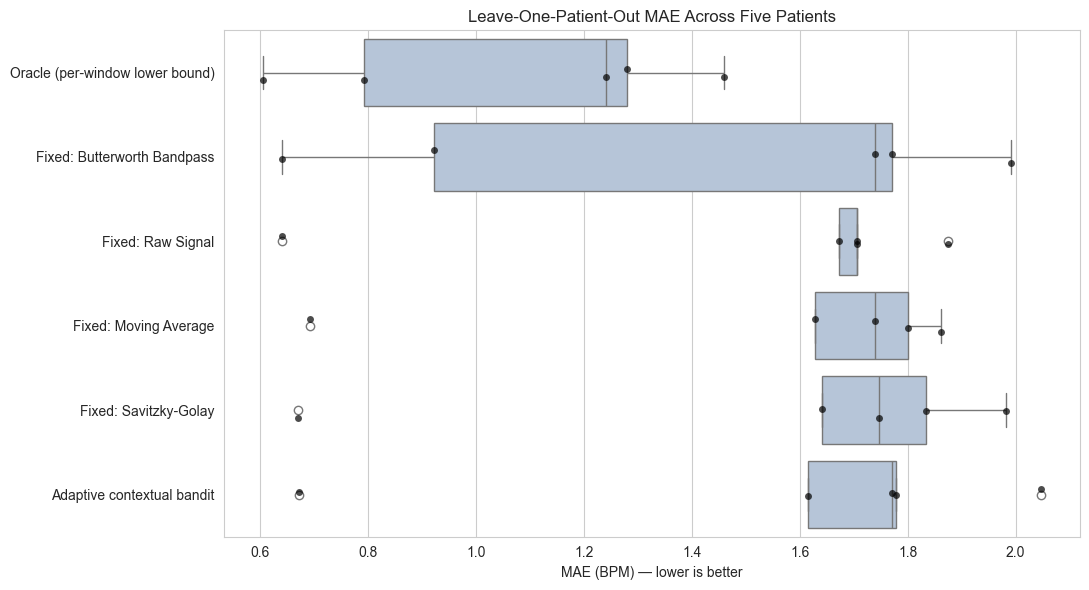

In [36]:
plot_order = paper_summary['Method'].tolist()
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=paper_fold_results,
    x='MAE (BPM)',
    y='Method',
    order=plot_order,
    color='lightsteelblue'
)
sns.stripplot(
    data=paper_fold_results,
    x='MAE (BPM)',
    y='Method',
    order=plot_order,
    color='black',
    size=5,
    alpha=0.7
)
plt.title('Leave-One-Patient-Out MAE Across Five Patients')
plt.xlabel('MAE (BPM) — lower is better')
plt.ylabel('')
plt.tight_layout()
plt.show()


## Minimum-publishable BIDMC protocol

The following cells run all 53 BIDMC subjects with chronological consecutive-window episodes, subject-grouped cross-validation, parameterized filter actions, all requested baselines, metrics, significance tests, ablations, and epsilon sensitivity.

In [37]:
"""Minimum-publishable BIDMC 53-subject sequential RL experiment.

This inline section runs in monte_carlo.ipynb so every result table
and figure remains available in the notebook namespace.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import requests
requests.packages.urllib3.disable_warnings()
from scipy.signal import butter, find_peaks, savgol_filter, sosfiltfilt
from scipy.stats import pearsonr, ttest_rel, wilcoxon
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from IPython.display import display
from IPython.display import display

try:
    FS
except NameError:
    FS = 125
try:
    BASE_URL
except NameError:
    BASE_URL = "https://physionet.org/files/bidmc/1.0.0/bidmc_csv"

if "load_patient" not in globals():
    def load_patient(patient_id):
        signal_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Signals.csv"
        numeric_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Numerics.csv"
        signals = pd.read_csv(signal_url)
        numerics = pd.read_csv(numeric_url)
        signals.columns = signals.columns.str.strip()
        numerics.columns = numerics.columns.str.strip()
        return signals, numerics

PUBLISHABLE_SEED = 20260809
P_FULL_SUBJECTS = np.arange(1, 54, dtype=int)
P_WINDOW_SIZE = int(FS * 8)
P_STEP_SIZE = int(FS * 4)
P_CURRENT_FEATURES = ["sqi", "entropy", "peak_quality"]
P_FEATURE_NAMES = P_CURRENT_FEATURES + ["previous_hr", "previous_action"]


def p_load_patient(patient_id):
    """Load local BIDMC cache first; download only when the cache is absent."""
    cache_dir = Path('bidmc_cache')
    frames = []
    for suffix in ["Signals", "Numerics"]:
        local_path = cache_dir / f"bidmc_{int(patient_id):02d}_{suffix}.csv"
        if local_path.exists():
            frame = pd.read_csv(local_path)
        else:
            url = f"{BASE_URL}/bidmc_{int(patient_id):02d}_{suffix}.csv"
            response = requests.get(url, timeout=60, verify=False)
            response.raise_for_status()
            frame = pd.read_csv(io.BytesIO(response.content))
        frame.columns = frame.columns.str.strip()
        frames.append(frame)
    return frames[0], frames[1]

# Filter family and parameter are both part of the action.
P_ACTION_SPECS = {
    0: {"name": "Raw", "kind": "raw"},
    1: {"name": "Moving average (5)", "kind": "moving_average", "window": 5},
    2: {"name": "Moving average (11)", "kind": "moving_average", "window": 11},
    3: {"name": "Savitzky-Golay (21,3)", "kind": "savgol", "window": 21, "polyorder": 3},
    4: {"name": "Butterworth (0.5-5 Hz, order 4)", "kind": "butter", "low": 0.5, "high": 5.0, "order": 4},
    5: {"name": "Butterworth (0.7-4 Hz, order 3)", "kind": "butter", "low": 0.7, "high": 4.0, "order": 3},
}
P_N_ACTIONS = len(P_ACTION_SPECS)


def p_apply_action(signal, action):
    x = np.asarray(signal, dtype=float)
    spec = P_ACTION_SPECS[int(action)]
    if spec["kind"] == "raw":
        return x.copy()
    if spec["kind"] == "moving_average":
        w = int(spec["window"])
        return np.convolve(x, np.ones(w) / w, mode="same")
    if spec["kind"] == "savgol":
        return savgol_filter(x, int(spec["window"]), int(spec["polyorder"]))
    sos = butter(
        int(spec["order"]), [spec["low"], spec["high"]],
        btype="bandpass", fs=FS, output="sos"
    )
    return sosfiltfilt(sos, x)


def p_hr_estimate(signal):
    x = np.asarray(signal, dtype=float)
    z = (x - np.nanmean(x)) / (np.nanstd(x) + 1e-8)
    peaks, _ = find_peaks(z, distance=int(0.5 * FS), prominence=0.35)
    if len(peaks) < 2:
        return np.nan
    hr = 60.0 / np.median(np.diff(peaks) / FS)
    return float(hr) if 35 <= hr <= 220 else np.nan


def p_noise_score(signal):
    x = np.asarray(signal, dtype=float)
    smooth = savgol_filter(x, window_length=31, polyorder=3)
    return float(np.std(x - smooth) / (np.std(x) + 1e-8))


def p_window_features(signal):
    x = np.asarray(signal, dtype=float)
    z = (x - np.nanmedian(x)) / (np.nanstd(x) + 1e-8)
    sqi = float(np.clip(1.0 / (1.0 + p_noise_score(x)), 0.0, 1.0))

    hist, _ = np.histogram(z[np.isfinite(z)], bins=32)
    probability = hist.astype(float)
    probability /= probability.sum() + 1e-12
    nonzero = probability > 0
    entropy_value = float(
        -np.sum(probability[nonzero] * np.log2(probability[nonzero])) / np.log2(32)
    )

    peaks, properties = find_peaks(z, distance=int(0.5 * FS), prominence=0.25)
    if len(peaks) >= 2 and len(properties.get("prominences", [])):
        rr = np.diff(peaks) / FS
        regularity = float(np.exp(-np.std(rr) / (np.mean(rr) + 1e-8)))
        prominence_quality = float(np.clip(np.median(properties["prominences"]) / 2.0, 0, 1))
        peak_quality = float(np.clip(0.5 * regularity + 0.5 * prominence_quality, 0, 1))
    else:
        peak_quality = 0.0
    return {"sqi": sqi, "entropy": entropy_value, "peak_quality": peak_quality}


In [38]:
# Download all 53 records concurrently once; the following dataset cell reuses this cache.
from concurrent.futures import ThreadPoolExecutor

def p_cached_record(patient_id):
    signals, numerics = p_load_patient(int(patient_id))
    return {"patient_id": int(patient_id), "signals": signals, "numerics": numerics}

with ThreadPoolExecutor(max_workers=8) as executor:
    P_FULL_DATA_CACHE = list(executor.map(p_cached_record, P_FULL_SUBJECTS))
P_FULL_DATA_BY_ID = {item["patient_id"]: item for item in P_FULL_DATA_CACHE}

def p_load_patient(patient_id):
    return P_FULL_DATA_BY_ID[int(patient_id)]["signals"], P_FULL_DATA_BY_ID[int(patient_id)]["numerics"]

print("Cached records:", len(P_FULL_DATA_CACHE))


Cached records: 53


In [39]:
def p_build_window_dataset(patient_data):
    rows = []
    for item in patient_data:
        patient_id = int(item["patient_id"])
        signals = item["signals"].copy()
        numerics = item["numerics"].copy()
        signal_time = pd.to_numeric(signals["Time [s]"], errors="coerce").to_numpy()
        ppg = pd.to_numeric(signals["PLETH"], errors="coerce").interpolate().bfill().ffill().to_numpy(dtype=float)
        numeric_time = pd.to_numeric(numerics["Time [s]"], errors="coerce").to_numpy(dtype=float)
        pulse = pd.to_numeric(numerics["PULSE"], errors="coerce").to_numpy(dtype=float)
        valid = np.isfinite(numeric_time) & np.isfinite(pulse)
        if not valid.any():
            raise ValueError(f"No valid PULSE reference for patient {patient_id}")
        valid_times, valid_pulse = numeric_time[valid], pulse[valid]
        window_number = 0
        for start in range(0, len(ppg) - P_WINDOW_SIZE + 1, P_STEP_SIZE):
            end = start + P_WINDOW_SIZE
            start_time, end_time = float(signal_time[start]), float(signal_time[end - 1])
            mid_time = float(signal_time[start + P_WINDOW_SIZE // 2])
            inside = valid & (numeric_time >= start_time) & (numeric_time <= end_time)
            values = pulse[inside]
            values = values[np.isfinite(values)]
            reference_hr = float(np.median(values)) if len(values) else float(np.interp(mid_time, valid_times, valid_pulse))
            row = {
                "patient_id": patient_id,
                "episode_id": patient_id,
                "window_number": window_number,
                "start_time": start_time,
                "end_time": end_time,
                "mid_time": mid_time,
                "ppg_signal": ppg[start:end].copy(),
                "reference_hr": float(np.clip(reference_hr, 35, 220)),
            }
            row.update(p_window_features(ppg[start:end]))
            rows.append(row)
            window_number += 1
    return pd.DataFrame(rows)


print("Loading all 53 BIDMC subjects...")
P_FULL_DATA = []
for patient_id in P_FULL_SUBJECTS:
    signals, numerics = p_load_patient(int(patient_id))
    P_FULL_DATA.append({"patient_id": int(patient_id), "signals": signals, "numerics": numerics})

PUBLISHABLE_DF = p_build_window_dataset(P_FULL_DATA).sort_values(
    ["patient_id", "window_number"]
).reset_index(drop=True)
P_EPISODES = {
    int(patient_id): group.index.to_numpy(dtype=int)
    for patient_id, group in PUBLISHABLE_DF.groupby("patient_id", sort=True)
}
assert set(P_EPISODES) == set(P_FULL_SUBJECTS)
assert all(
    len(indices) < 2 or np.all(np.diff(PUBLISHABLE_DF.loc[indices, "window_number"]) == 1)
    for indices in P_EPISODES.values()
)

P_ESTIMATE_MATRIX = np.full((len(PUBLISHABLE_DF), P_N_ACTIONS), np.nan)
for row_index, row in enumerate(PUBLISHABLE_DF.itertuples(index=False)):
    for action in range(P_N_ACTIONS):
        try:
            P_ESTIMATE_MATRIX[row_index, action] = p_hr_estimate(p_apply_action(row.ppg_signal, action))
        except Exception:
            pass
P_REFERENCE = PUBLISHABLE_DF["reference_hr"].to_numpy(dtype=float)
P_ERROR_MATRIX = np.abs(P_ESTIMATE_MATRIX - P_REFERENCE[:, None])
P_ERROR_MATRIX = np.where(np.isfinite(P_ERROR_MATRIX), np.minimum(P_ERROR_MATRIX, 50), 50)
P_REWARD_MATRIX = -P_ERROR_MATRIX
P_FEATURE_ARRAYS = {feature: PUBLISHABLE_DF[feature].to_numpy(dtype=float) for feature in P_CURRENT_FEATURES}
P_WINDOW_NUMBER_ARRAY = PUBLISHABLE_DF["window_number"].to_numpy(dtype=int)


Loading all 53 BIDMC subjects...


In [40]:
def p_edges(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if not len(values):
        return np.array([0.0, 1.0])
    q1, q2 = np.quantile(values, [0.33, 0.66])
    if q2 <= q1:
        q2 = q1 + max(1e-6, abs(q1) * 1e-6)
    return np.array([q1, q2])


def p_fit_encoder(train_indices, feature_names=P_FEATURE_NAMES):
    feature_names = list(feature_names)
    encoder = {
        "feature_names": feature_names,
        "initial_hr": float(np.median(P_REFERENCE[train_indices])),
        "edges": {},
    }
    for feature in P_CURRENT_FEATURES:
        if feature in feature_names:
            encoder["edges"][feature] = p_edges(PUBLISHABLE_DF.iloc[train_indices][feature])
    if "previous_hr" in feature_names:
        encoder["edges"]["previous_hr"] = p_edges(P_REFERENCE[train_indices])
    dimensions = [P_N_ACTIONS + 1 if f == "previous_action" else 3 for f in feature_names]
    encoder["dimensions"] = tuple(dimensions)
    encoder["n_states"] = int(np.prod(dimensions)) if dimensions else 1
    return encoder


def p_state_id(row_index, previous_hr, previous_action, encoder):
    coordinates = []
    for feature in encoder["feature_names"]:
        if feature in P_CURRENT_FEATURES:
            value = float(P_FEATURE_ARRAYS[feature][row_index])
            coordinates.append(int(np.digitize(value, encoder["edges"][feature])))
        elif feature == "previous_hr":
            coordinates.append(int(np.digitize(previous_hr, encoder["edges"][feature])))
        elif feature == "previous_action":
            coordinates.append(int(previous_action) + 1)
    return int(np.ravel_multi_index(tuple(coordinates), encoder["dimensions"])) if coordinates else 0


def p_context(row_index, previous_hr, previous_action, feature_names):
    values = []
    for feature in feature_names:
        if feature in P_CURRENT_FEATURES:
            values.append(float(P_FEATURE_ARRAYS[feature][row_index]))
        elif feature == "previous_hr":
            values.append(float(previous_hr))
        elif feature == "previous_action":
            values.append(float(previous_action))
    return np.asarray(values, dtype=float)


def p_choose(q_values, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(P_N_ACTIONS))
    return int(rng.choice(np.flatnonzero(q_values[state] == q_values[state].max())))


def p_train_tabular(train_indices, train_subjects, encoder, algorithm="q", seed=11,
                    epochs=40, epsilon_start=1.0, epsilon_min=0.05,
                    epsilon_decay=0.97, gamma=0.95):
    rng = np.random.default_rng(seed)
    q_values = np.zeros((encoder["n_states"], P_N_ACTIONS))
    visits = np.zeros_like(q_values, dtype=int)
    return_sum = np.zeros_like(q_values)
    return_count = np.zeros_like(q_values, dtype=int)
    train_set = set(map(int, train_indices))
    episodes = [
        np.asarray([i for i in P_EPISODES[int(pid)] if int(i) in train_set])
        for pid in np.sort(train_subjects)
    ]
    episodes = [episode for episode in episodes if len(episode)]
    epsilon = float(epsilon_start)
    for _ in range(int(epochs)):
        for episode_position in rng.permutation(len(episodes)):
            episode = episodes[int(episode_position)]
            previous_hr, previous_action, trajectory = encoder["initial_hr"], -1, []
            for position, row_index in enumerate(episode):
                state = p_state_id(row_index, previous_hr, previous_action, encoder)
                action = p_choose(q_values, state, epsilon, rng)
                prediction = P_ESTIMATE_MATRIX[row_index, action]
                next_hr = float(prediction) if np.isfinite(prediction) else encoder["initial_hr"]
                reward = float(P_REWARD_MATRIX[row_index, action])
                if previous_action >= 0 and action != previous_action:
                    reward -= 0.10
                trajectory.append((state, action, reward))
                if algorithm == "q":
                    if position + 1 < len(episode):
                        next_state = p_state_id(episode[position + 1], next_hr, action, encoder)
                        target = reward + gamma * q_values[next_state].max()
                    else:
                        target = reward
                    visits[state, action] += 1
                    alpha = 0.10 / np.sqrt(visits[state, action])
                    q_values[state, action] += alpha * (target - q_values[state, action])
                elif algorithm == "bandit":
                    visits[state, action] += 1
                    alpha = 1.0 / visits[state, action]
                    q_values[state, action] += alpha * (reward - q_values[state, action])
                elif algorithm != "mc":
                    raise ValueError("algorithm must be mc, q, or bandit")
                previous_hr, previous_action = next_hr, action
            if algorithm == "mc":
                discounted_return = 0.0
                for state, action, reward in reversed(trajectory):
                    discounted_return = reward + gamma * discounted_return
                    return_count[state, action] += 1
                    return_sum[state, action] += discounted_return
                    q_values[state, action] = return_sum[state, action] / return_count[state, action]
        epsilon = max(float(epsilon_min), epsilon * float(epsilon_decay))
    return q_values


def p_rollout(indices, encoder, policy_kind, q_values=None, fixed_action=None, model=None):
    index_set = set(map(int, indices))
    records = []
    for patient_id in sorted(P_EPISODES):
        episode = [i for i in P_EPISODES[patient_id] if int(i) in index_set]
        if not episode:
            continue
        previous_hr, previous_action = encoder["initial_hr"], -1
        for row_index in episode:
            state = p_state_id(row_index, previous_hr, previous_action, encoder)
            if policy_kind == "fixed":
                action = int(fixed_action)
            elif policy_kind == "table":
                action = int(np.argmax(q_values[state]))
            else:
                action = int(model.predict(p_context(row_index, previous_hr, previous_action, encoder["feature_names"]).reshape(1, -1))[0])
            prediction = P_ESTIMATE_MATRIX[row_index, action]
            records.append({
                "row_index": int(row_index), "patient_id": int(patient_id),
                "window_number": int(P_WINDOW_NUMBER_ARRAY[row_index]),
                "reference_hr": float(P_REFERENCE[row_index]),
                "prediction": float(prediction) if np.isfinite(prediction) else np.nan,
                "action": action,
            })
            previous_hr = float(prediction) if np.isfinite(prediction) else encoder["initial_hr"]
            previous_action = action
    return pd.DataFrame(records)


def p_metrics(predictions, references):
    predictions, references = np.asarray(predictions, dtype=float), np.asarray(references, dtype=float)
    finite = np.isfinite(predictions) & np.isfinite(references)
    errors = np.where(finite, np.minimum(np.abs(predictions - references), 50), 50)
    correlation = np.nan
    if finite.sum() >= 2 and np.std(predictions[finite]) > 0 and np.std(references[finite]) > 0:
        correlation = float(pearsonr(predictions[finite], references[finite]).statistic)
    difference = predictions[finite] - references[finite]
    bias = float(np.mean(difference)) if len(difference) else np.nan
    loa_sd = float(np.std(difference, ddof=1)) if len(difference) > 1 else 0.0
    return {
        "N windows": int(len(references)), "MAE (BPM)": float(errors.mean()),
        "RMSE (BPM)": float(np.sqrt(np.mean(errors ** 2))), "Correlation": correlation,
        "BA bias (BPM)": bias,
        "BA lower LoA (BPM)": bias - 1.96 * loa_sd if np.isfinite(bias) else np.nan,
        "BA upper LoA (BPM)": bias + 1.96 * loa_sd if np.isfinite(bias) else np.nan,
        "Failed (%)": float(100 * (1 - finite.mean())) if len(finite) else np.nan,
    }


def p_fit_supervised(train_indices, train_subjects, encoder, seed=11):
    x_rows, y_rows = [], []
    train_set = set(map(int, train_indices))
    for patient_id in sorted(train_subjects):
        episode = [i for i in P_EPISODES[int(patient_id)] if int(i) in train_set]
        for position, row_index in enumerate(episode):
            previous_options = [-1] if position == 0 else range(P_N_ACTIONS)
            for previous_action in previous_options:
                if previous_action < 0:
                    previous_hr = encoder["initial_hr"]
                else:
                    previous_prediction = P_ESTIMATE_MATRIX[episode[position - 1], previous_action]
                    previous_hr = float(previous_prediction) if np.isfinite(previous_prediction) else encoder["initial_hr"]
                x_rows.append(p_context(row_index, previous_hr, previous_action, encoder["feature_names"]))
                y_rows.append(int(np.argmin(P_ERROR_MATRIX[row_index])))
    model = DummyClassifier(strategy="most_frequent") if len(np.unique(y_rows)) < 2 else RandomForestClassifier(
        n_estimators=100, max_depth=12, min_samples_leaf=3, random_state=seed, n_jobs=-1
    )
    model.fit(np.asarray(x_rows), np.asarray(y_rows))
    return model


In [41]:
# Subject-independent 5-fold CV; every subject is held out exactly once.
P_GROUPS = PUBLISHABLE_DF["patient_id"].to_numpy()
P_SPLITS = list(GroupKFold(n_splits=5).split(np.zeros(len(PUBLISHABLE_DF)), groups=P_GROUPS))
P_TRAIN_SEEDS, P_AGENT_EPOCHS = [11, 22, 33], 40
P_RESULTS_ROWS, P_PREDICTION_STORE = [], {}


def p_add_result(fold, method, seed, rollout):
    metrics = p_metrics(rollout.prediction, rollout.reference_hr)
    row = {"Fold": fold, "Method": method, "Seed": seed}
    row.update(metrics)
    P_RESULTS_ROWS.append(row)
    P_PREDICTION_STORE[(fold, method, seed)] = rollout


for fold, (train_indices, test_indices) in enumerate(P_SPLITS, 1):
    train_subjects = np.sort(pd.unique(P_GROUPS[train_indices]))
    encoder = p_fit_encoder(train_indices)
    for action, spec in P_ACTION_SPECS.items():
        p_add_result(fold, "Fixed | " + spec["name"], 0, p_rollout(test_indices, encoder, "fixed", fixed_action=action))
    for seed in P_TRAIN_SEEDS:
        for algorithm, method in [("mc", "Monte-Carlo"), ("q", "Q-learning"), ("bandit", "Contextual bandit")]:
            q_values = p_train_tabular(train_indices, train_subjects, encoder, algorithm, seed, P_AGENT_EPOCHS)
            p_add_result(fold, method, seed, p_rollout(test_indices, encoder, "table", q_values=q_values))
    model = p_fit_supervised(train_indices, train_subjects, encoder, P_TRAIN_SEEDS[0])
    p_add_result(fold, "Supervised action classifier", P_TRAIN_SEEDS[0], p_rollout(test_indices, encoder, "model", model=model))

P_RESULTS = pd.DataFrame(P_RESULTS_ROWS)
P_FOLD_RESULTS = P_RESULTS.groupby(["Fold", "Method"], as_index=False).agg({
    "MAE (BPM)": "mean", "RMSE (BPM)": "mean", "Correlation": "mean",
    "BA bias (BPM)": "mean", "BA lower LoA (BPM)": "mean", "BA upper LoA (BPM)": "mean",
    "Failed (%)": "mean", "N windows": "first",
})
P_METHOD_ORDER = P_FOLD_RESULTS.groupby("Method")["MAE (BPM)"].mean().sort_values().index.tolist()


def p_summary_table(frame):
    rows = []
    for method, group in frame.groupby("Method"):
        for metric in ["MAE (BPM)", "RMSE (BPM)", "Correlation"]:
            values = group[metric].to_numpy(float)
            rows.append({"Method": method, "Metric": metric, "Mean": np.nanmean(values), "SD": np.nanstd(values, ddof=1), "N folds": len(values)})
    return pd.DataFrame(rows)


P_SUMMARY = p_summary_table(P_FOLD_RESULTS)
print("Subjects: {}, windows: {}, grouped folds: {}".format(PUBLISHABLE_DF.patient_id.nunique(), len(PUBLISHABLE_DF), len(P_SPLITS)))
display(P_SUMMARY.round(3))


Subjects: 53, windows: 6307, grouped folds: 5


,Method,Metric,Mean,SD,N folds
0,Contextual bandit,MAE (BPM),3.787,4.290,5
1,Contextual bandit,RMSE (BPM),7.752,7.902,5
2,Contextual bandit,Correlation,0.764,0.366,5
3,"Fixed | Butterworth (0.5-5 Hz, order 4)",MAE (BPM),3.763,4.270,5
4,"Fixed | Butterworth (0.5-5 Hz, order 4)",RMSE (BPM),7.653,7.926,5
5,"Fixed | Butterworth (0.5-5 Hz, order 4)",Correlation,0.763,0.367,5
6,"Fixed | Butterworth (0.7-4 Hz, order 3)",MAE (BPM),3.743,4.278,5
7,"Fixed | Butterworth (0.7-4 Hz, order 3)",RMSE (BPM),7.533,7.946,5
8,"Fixed | Butterworth (0.7-4 Hz, order 3)",Correlation,0.765,0.363,5
9,Fixed | Moving average (11),MAE (BPM),3.809,4.287,5


In [42]:
# Paired tests are on fold-level MAE, not correlated windows.
P_REFERENCE_METHOD = "Q-learning"
P_SIGNIFICANCE_ROWS = []
for method in P_FOLD_RESULTS.Method.unique():
    if method == P_REFERENCE_METHOD:
        continue
    paired = P_FOLD_RESULTS[P_FOLD_RESULTS.Method.isin([P_REFERENCE_METHOD, method])].pivot(index="Fold", columns="Method", values="MAE (BPM)").dropna()
    q, other = paired[P_REFERENCE_METHOD].to_numpy(), paired[method].to_numpy()
    try:
        t_p = float(ttest_rel(q, other).pvalue)
    except Exception:
        t_p = np.nan
    try:
        w_p = float(wilcoxon(q, other).pvalue)
    except Exception:
        w_p = np.nan
    P_SIGNIFICANCE_ROWS.append({"Comparison": "{} vs {}".format(P_REFERENCE_METHOD, method), "Paired t-test p": t_p, "Wilcoxon signed-rank p": w_p, "N folds": len(paired)})
P_SIGNIFICANCE = pd.DataFrame(P_SIGNIFICANCE_ROWS)
if len(P_SIGNIFICANCE):
    valid = P_SIGNIFICANCE["Wilcoxon signed-rank p"].notna()
    pvals = P_SIGNIFICANCE.loc[valid, "Wilcoxon signed-rank p"].to_numpy()
    order = np.argsort(pvals)
    adjusted = np.empty(len(pvals))
    adjusted[order] = np.minimum(1, np.maximum.accumulate(pvals[order] * np.arange(len(pvals), 0, -1)))
    P_SIGNIFICANCE.loc[valid, "Wilcoxon Holm p"] = adjusted
display(P_SIGNIFICANCE.round(4))


,Comparison,Paired t-test p,Wilcoxon signed-rank p,N folds,Wilcoxon Holm p
0,Q-learning vs Contextual bandit,0.1116,0.3125,5,1.0000
1,"Q-learning vs Fixed | Butterworth (0.5-5 Hz, o...",0.9507,0.8125,5,1.0000
2,"Q-learning vs Fixed | Butterworth (0.7-4 Hz, o...",0.0071,0.0625,5,0.5625
3,Q-learning vs Fixed | Moving average (11),0.0504,0.0625,5,0.5625
4,Q-learning vs Fixed | Moving average (5),0.1452,0.0625,5,0.5625
5,Q-learning vs Fixed | Raw,0.1028,0.1250,5,0.6250
6,"Q-learning vs Fixed | Savitzky-Golay (21,3)",0.4495,0.4375,5,1.0000
7,Q-learning vs Monte-Carlo,0.0222,0.0625,5,0.5625
8,Q-learning vs Supervised action classifier,0.3193,0.3125,5,1.0000


In [43]:
# Bland-Altman metrics over all held-out windows.
P_BA_ROWS = []
for method in P_METHOD_ORDER:
    keys = [k for k in P_PREDICTION_STORE if k[1] == method and k[2] in [0, P_TRAIN_SEEDS[0]]]
    combined = pd.concat([P_PREDICTION_STORE[k] for k in sorted(keys)], ignore_index=True)
    metrics = p_metrics(combined.prediction, combined.reference_hr)
    P_BA_ROWS.append({"Method": method, "Bias (BPM)": metrics["BA bias (BPM)"], "Lower LoA (BPM)": metrics["BA lower LoA (BPM)"], "Upper LoA (BPM)": metrics["BA upper LoA (BPM)"], "MAE (BPM)": metrics["MAE (BPM)"], "RMSE (BPM)": metrics["RMSE (BPM)"]})
P_BA_SUMMARY = pd.DataFrame(P_BA_ROWS)
display(P_BA_SUMMARY.round(3))


,Method,Bias (BPM),Lower LoA (BPM),Upper LoA (BPM),MAE (BPM),RMSE (BPM)
0,"Fixed | Butterworth (0.7-4 Hz, order 3)",-2.413,-26.832,22.006,3.819,10.522
1,"Fixed | Butterworth (0.5-5 Hz, order 4)",-2.449,-27.186,22.288,3.838,10.598
2,Q-learning,-2.358,-26.899,22.183,3.861,10.660
3,"Fixed | Savitzky-Golay (21,3)",-2.364,-26.998,22.270,3.854,10.655
4,Contextual bandit,-2.364,-26.859,22.132,3.845,10.626
5,Supervised action classifier,-2.408,-27.079,22.263,3.863,10.661
6,Monte-Carlo,-2.386,-27.039,22.267,3.874,10.711
7,Fixed | Raw,-2.415,-27.082,22.251,3.878,10.688
8,Fixed | Moving average (11),-2.305,-26.972,22.363,3.885,10.716
9,Fixed | Moving average (5),-2.294,-26.886,22.298,3.892,10.720


In [44]:
# State ablation and epsilon sensitivity.
P_ABLATION_FEATURES = {
    "Full state": P_FEATURE_NAMES,
    "No SQI": ["entropy", "peak_quality", "previous_hr", "previous_action"],
    "No entropy": ["sqi", "peak_quality", "previous_hr", "previous_action"],
    "No peak quality": ["sqi", "entropy", "previous_hr", "previous_action"],
    "No previous HR": ["sqi", "entropy", "peak_quality", "previous_action"],
    "No previous action": ["sqi", "entropy", "peak_quality", "previous_hr"],
}
P_ABLATION_ROWS = []
for name, features in P_ABLATION_FEATURES.items():
    for fold, (train_indices, test_indices) in enumerate(P_SPLITS, 1):
        subjects = np.sort(pd.unique(P_GROUPS[train_indices]))
        encoder = p_fit_encoder(train_indices, features)
        q_values = p_train_tabular(train_indices, subjects, encoder, "q", 11, 25)
        metrics = p_metrics(*(p_rollout(test_indices, encoder, "table", q_values=q_values)[c] for c in ["prediction", "reference_hr"]))
        P_ABLATION_ROWS.append({"Ablation": name, "Fold": fold, **{k: metrics[k] for k in ["MAE (BPM)", "RMSE (BPM)", "Correlation"]}})
P_ABLATION = pd.DataFrame(P_ABLATION_ROWS)
P_ABLATION_SUMMARY = P_ABLATION.groupby("Ablation", as_index=False).agg({"MAE (BPM)": ["mean", "std"], "RMSE (BPM)": ["mean", "std"], "Correlation": "mean"})
P_ABLATION_SUMMARY.columns = ["Ablation", "MAE mean", "MAE SD", "RMSE mean", "RMSE SD", "Correlation mean"]
display(P_ABLATION_SUMMARY.round(3))

P_EPSILON_GRID = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80]
P_EPSILON_ROWS = []
for epsilon_start in P_EPSILON_GRID:
    for fold, (train_indices, test_indices) in enumerate(P_SPLITS, 1):
        subjects = np.sort(pd.unique(P_GROUPS[train_indices]))
        encoder = p_fit_encoder(train_indices)
        q_values = p_train_tabular(train_indices, subjects, encoder, "q", 11, 25, epsilon_start, 0.0, 0.95)
        metrics = p_metrics(*(p_rollout(test_indices, encoder, "table", q_values=q_values)[c] for c in ["prediction", "reference_hr"]))
        P_EPSILON_ROWS.append({"Initial epsilon": epsilon_start, "Fold": fold, **{k: metrics[k] for k in ["MAE (BPM)", "RMSE (BPM)", "Correlation"]}})
P_EPSILON = pd.DataFrame(P_EPSILON_ROWS)
P_EPSILON_SUMMARY = P_EPSILON.groupby("Initial epsilon", as_index=False).agg({"MAE (BPM)": ["mean", "std"], "RMSE (BPM)": ["mean", "std"], "Correlation": "mean"})
P_EPSILON_SUMMARY.columns = ["Initial epsilon", "MAE mean", "MAE SD", "RMSE mean", "RMSE SD", "Correlation mean"]
display(P_EPSILON_SUMMARY.round(3))


,Ablation,MAE mean,MAE SD,RMSE mean,RMSE SD,Correlation mean
0,Full state,3.758,4.289,7.654,7.984,0.767
1,No SQI,3.783,4.320,7.690,7.967,0.768
2,No entropy,3.833,4.340,7.790,7.960,0.761
3,No peak quality,3.757,4.291,7.579,7.977,0.769
4,No previous HR,3.795,4.281,7.710,7.915,0.766
5,No previous action,3.803,4.307,7.800,7.912,0.763


,Initial epsilon,MAE mean,MAE SD,RMSE mean,RMSE SD,Correlation mean
0,0.00,3.782,4.283,7.747,7.896,0.764
1,0.05,3.757,4.259,7.650,7.885,0.764
2,0.10,3.765,4.292,7.649,7.951,0.768
3,0.20,3.802,4.304,7.771,7.914,0.766
4,0.40,3.785,4.308,7.693,7.960,0.765
5,0.80,3.778,4.297,7.682,7.932,0.765


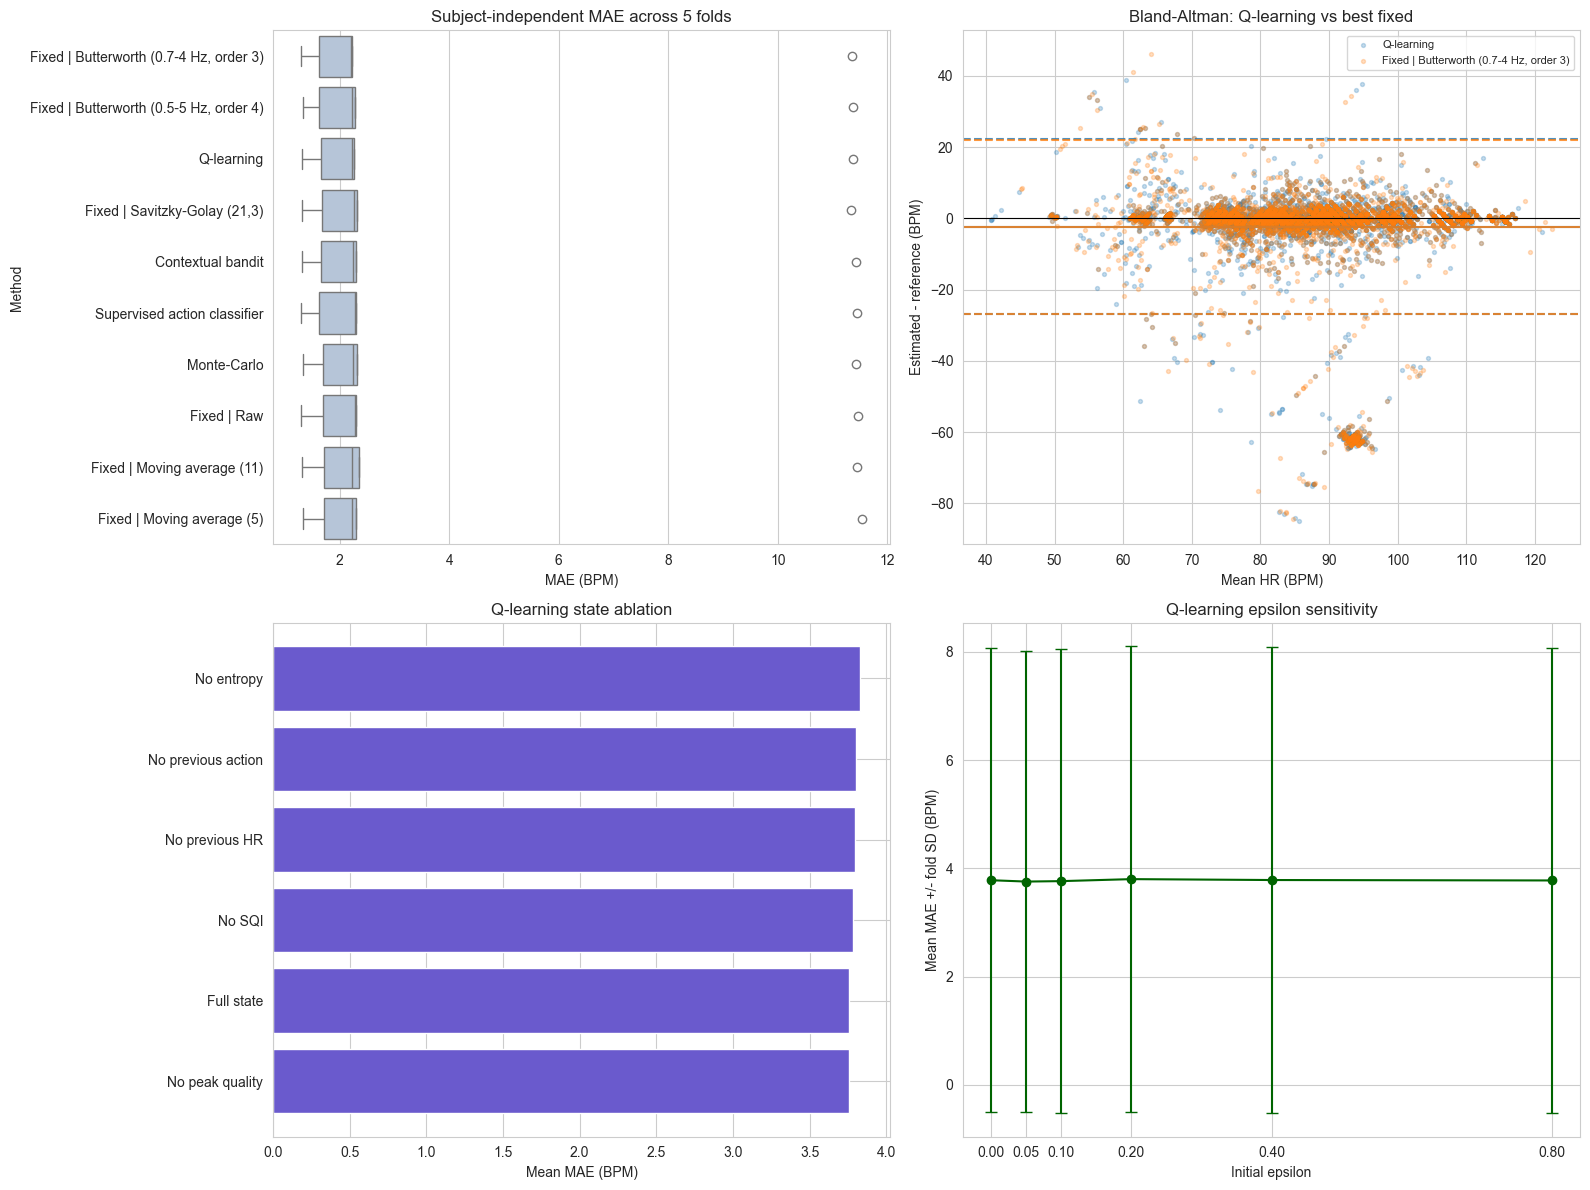

Best fixed filter: Fixed | Butterworth (0.7-4 Hz, order 3)
All 53 subjects are held out exactly once: True


In [45]:
# Compact publication-oriented visualization.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.boxplot(data=P_FOLD_RESULTS, x="MAE (BPM)", y="Method", order=P_METHOD_ORDER, ax=axes[0, 0], color="lightsteelblue")
axes[0, 0].set_title("Subject-independent MAE across 5 folds")
best_fixed_method = P_FOLD_RESULTS[P_FOLD_RESULTS.Method.str.startswith("Fixed |")].groupby("Method")["MAE (BPM)"].mean().idxmin()
for method, color in [(P_REFERENCE_METHOD, "tab:blue"), (best_fixed_method, "tab:orange")]:
    keys = [k for k in P_PREDICTION_STORE if k[1] == method and k[2] in [0, P_TRAIN_SEEDS[0]]]
    combined = pd.concat([P_PREDICTION_STORE[k] for k in sorted(keys)], ignore_index=True).dropna(subset=["prediction"])
    mean_hr = (combined.prediction + combined.reference_hr) / 2
    difference = combined.prediction - combined.reference_hr
    axes[0, 1].scatter(mean_hr, difference, s=8, alpha=0.25, label=method, color=color)
    bias, sd = difference.mean(), difference.std(ddof=1)
    for value, style in [(bias, "-"), (bias + 1.96 * sd, "--"), (bias - 1.96 * sd, "--")]:
        axes[0, 1].axhline(value, color=color, linestyle=style, alpha=0.8)
axes[0, 1].axhline(0, color="black", linewidth=0.8)
axes[0, 1].set_title("Bland-Altman: Q-learning vs best fixed")
axes[0, 1].set_xlabel("Mean HR (BPM)")
axes[0, 1].set_ylabel("Estimated - reference (BPM)")
axes[0, 1].legend(fontsize=8)
ablation_plot = P_ABLATION_SUMMARY.sort_values("MAE mean")
axes[1, 0].barh(ablation_plot.Ablation, ablation_plot["MAE mean"], color="slateblue")
axes[1, 0].set_title("Q-learning state ablation")
axes[1, 0].set_xlabel("Mean MAE (BPM)")
axes[1, 1].errorbar(P_EPSILON_SUMMARY["Initial epsilon"], P_EPSILON_SUMMARY["MAE mean"], yerr=P_EPSILON_SUMMARY["MAE SD"], marker="o", capsize=4, color="darkgreen")
axes[1, 1].set_title("Q-learning epsilon sensitivity")
axes[1, 1].set_xlabel("Initial epsilon")
axes[1, 1].set_ylabel("Mean MAE +/- fold SD (BPM)")
axes[1, 1].set_xticks(P_EPSILON_GRID)
plt.tight_layout()
plt.show()

print("Best fixed filter:", best_fixed_method)
print("All 53 subjects are held out exactly once:", len(np.unique(np.concatenate([P_GROUPS[test] for _, test in P_SPLITS]))) == 53)


In [46]:
# Key publication tables remain available as notebook variables.
print('Main comparison table')
display(P_SUMMARY.round(3))
print('Significance tests')
display(P_SIGNIFICANCE.round(4))
print('Bland-Altman summary')
display(P_BA_SUMMARY.round(3))
print('Ablation summary')
display(P_ABLATION_SUMMARY.round(3))
print('Epsilon sensitivity summary')
display(P_EPSILON_SUMMARY.round(3))


Main comparison table


,Method,Metric,Mean,SD,N folds
0,Contextual bandit,MAE (BPM),3.787,4.290,5
1,Contextual bandit,RMSE (BPM),7.752,7.902,5
2,Contextual bandit,Correlation,0.764,0.366,5
3,"Fixed | Butterworth (0.5-5 Hz, order 4)",MAE (BPM),3.763,4.270,5
4,"Fixed | Butterworth (0.5-5 Hz, order 4)",RMSE (BPM),7.653,7.926,5
5,"Fixed | Butterworth (0.5-5 Hz, order 4)",Correlation,0.763,0.367,5
6,"Fixed | Butterworth (0.7-4 Hz, order 3)",MAE (BPM),3.743,4.278,5
7,"Fixed | Butterworth (0.7-4 Hz, order 3)",RMSE (BPM),7.533,7.946,5
8,"Fixed | Butterworth (0.7-4 Hz, order 3)",Correlation,0.765,0.363,5
9,Fixed | Moving average (11),MAE (BPM),3.809,4.287,5


Significance tests


,Comparison,Paired t-test p,Wilcoxon signed-rank p,N folds,Wilcoxon Holm p
0,Q-learning vs Contextual bandit,0.1116,0.3125,5,1.0000
1,"Q-learning vs Fixed | Butterworth (0.5-5 Hz, o...",0.9507,0.8125,5,1.0000
2,"Q-learning vs Fixed | Butterworth (0.7-4 Hz, o...",0.0071,0.0625,5,0.5625
3,Q-learning vs Fixed | Moving average (11),0.0504,0.0625,5,0.5625
4,Q-learning vs Fixed | Moving average (5),0.1452,0.0625,5,0.5625
5,Q-learning vs Fixed | Raw,0.1028,0.1250,5,0.6250
6,"Q-learning vs Fixed | Savitzky-Golay (21,3)",0.4495,0.4375,5,1.0000
7,Q-learning vs Monte-Carlo,0.0222,0.0625,5,0.5625
8,Q-learning vs Supervised action classifier,0.3193,0.3125,5,1.0000


Bland-Altman summary


,Method,Bias (BPM),Lower LoA (BPM),Upper LoA (BPM),MAE (BPM),RMSE (BPM)
0,"Fixed | Butterworth (0.7-4 Hz, order 3)",-2.413,-26.832,22.006,3.819,10.522
1,"Fixed | Butterworth (0.5-5 Hz, order 4)",-2.449,-27.186,22.288,3.838,10.598
2,Q-learning,-2.358,-26.899,22.183,3.861,10.660
3,"Fixed | Savitzky-Golay (21,3)",-2.364,-26.998,22.270,3.854,10.655
4,Contextual bandit,-2.364,-26.859,22.132,3.845,10.626
5,Supervised action classifier,-2.408,-27.079,22.263,3.863,10.661
6,Monte-Carlo,-2.386,-27.039,22.267,3.874,10.711
7,Fixed | Raw,-2.415,-27.082,22.251,3.878,10.688
8,Fixed | Moving average (11),-2.305,-26.972,22.363,3.885,10.716
9,Fixed | Moving average (5),-2.294,-26.886,22.298,3.892,10.720


Ablation summary


,Ablation,MAE mean,MAE SD,RMSE mean,RMSE SD,Correlation mean
0,Full state,3.758,4.289,7.654,7.984,0.767
1,No SQI,3.783,4.320,7.690,7.967,0.768
2,No entropy,3.833,4.340,7.790,7.960,0.761
3,No peak quality,3.757,4.291,7.579,7.977,0.769
4,No previous HR,3.795,4.281,7.710,7.915,0.766
5,No previous action,3.803,4.307,7.800,7.912,0.763


Epsilon sensitivity summary


,Initial epsilon,MAE mean,MAE SD,RMSE mean,RMSE SD,Correlation mean
0,0.00,3.782,4.283,7.747,7.896,0.764
1,0.05,3.757,4.259,7.650,7.885,0.764
2,0.10,3.765,4.292,7.649,7.951,0.768
3,0.20,3.802,4.304,7.771,7.914,0.766
4,0.40,3.785,4.308,7.693,7.960,0.765
5,0.80,3.778,4.297,7.682,7.932,0.765


## External public-dataset replication: SensSmartTech

This is a separate public PPG dataset: 338 30-second recordings from 32 healthy volunteers, with ECG-derived reference HR. The experiment keeps the filter action space, reward (negative capped absolute HR error), epsilon-greedy Monte-Carlo/Q-learning/contextual-bandit policies, and subject-independent evaluation. It is not pooled with BIDMC because the populations, sensors, recording duration, and sampling rates differ.


In [47]:
# Downloads the public SensSmartTech PPG CSV files if needed, then runs the full replication.
# The implementation also saves seed-, fold-, summary-, and held-out-prediction CSVs in paper_outputs/.
# Full implementation is embedded here; no helper Python file is required.
import base64, zlib
exec(compile(zlib.decompress(base64.b85decode(b'c-qBVUvt|yl7IK7z;f%hK!>6w*-kR@a;u!gnVGuD#A|!*>Pn?jK_Vn^O_4M~*;2fIzvumk`$@LD0g#|1k3Dl+b*Y(%1R9M-|NQ|(JkPt5MVZH|X);MAyOx={UW&51k<$g6$ZWcRw_CPSGG>zvTjp6M$5T<Jd6*QNY!Z5&cQ7mSB`ZX=NRtUmmPKAx>=Ise$28BTtFn|?70y=Gs+7vo+$>5d;>$cwFV=Fps`65gSd}So3QKvnlB%-Q&|1o>Oys>hI52J5YFTWUP%JBKQz5b#8sNVowrxvM6=_}}(_({9)SXtgUr8~^%M4pprnC@h3JVNXGS5V6MVPFrN|pgrxtb+uh5y5gxS!|g7+<h&mSpj`km9z@rxI1YZeXISaVgV)JtXNgU+0;jy-lSkvv8TmG94?K%4wD4nH~3inXiif{G6w;CjaqrQ!Vl=j1yI)Vq?k7>%qbG`0DG|8y1l<xL2$uX)+zhq7q70>PUgH6&kw&V|zZ3f4u%Lpf<yfm<R73H2-q-6Eu5^sw&jr=%`q16i6kjFfZpvux`1<>!=rY!!C|I|9JD`*PpLp^y2}8KivWIuEc{EupT^p$?ubF&cwYe#auFe>O)6=Pe-o@J;dM`dauQOQhmGKbiU7V)x6&ej&bA(^nD-;J%Ab(jCaG+&MEuhTfp)%mL)r}Tuyf>-*rwLO5}I&1Pl0l9e_TrFD^dO!^P#-k3ZmYdfjfohP@uh+Yi|B@d&2x9vmFRa>mp+&L6Tg7cut-G@sUJxV(*%k{1GFK}9#^N(M}>6Yz!nmR|icMn*7{?LOiZ%Vj<<MX^Yxs%5HAPDeOZ_a2caGnRq3yQ4zlsz5Y1qWH{vBtt(P?QjZO<Fy>KQY<A1P{bj|@EGX0O9f$Zn?PcDP*KkhlQf?W2LT)OPDZWa^gGmldzY8rd!rEK%>?&H;WRHcT+fz4zpBX%VO-_~QieiRn?iC`m3~;|DXflLWz87)DaYZ)61rJcNhT<=BCT-HASeLoo*Lz~6j%>=QGdYh$YB+@gSA`_3HaP@^5aXf9)m;P$`Z8J_bEw1|A5h&@G)G9g2R#mtrB1J10hzBy+}K?59)lx*8vlhM2rGpLHeCV5r(4~yLQ#xqUqH%Sph`ZeV)Q{fi1j(BnqPT=rmxMvLa7`1l}Gd{g;?Pgdbrv{W_cDnoTR|A|prw5VbU90u{gpa>V!$(m=pY!!E|C-)4BiWU3_5yn|k%Ic_P{N%dT(e@>hOGtC5jFY@rE5K4i$XDZTpBVSd;s)E(z%JT!Z_G{ZLKxAW&Zz$rLbx;#aDKhBr!5cZesw##z_J;Lj=e-t+>Po=I7z=fs;gGf<=T{<|$|%Vy9`;WUQ3RM2LU5U65_`hq(^{pe%s7qp*`M3S$wWp(_aa?kgud;9G$dP`fOPN_C$pIye8gxTS7CY}%yE3m{v4TCc<A@LTG?ij+E1k*P_V0!wN{AM$C}j9)`nW<IYd&l<qe>Y<Hj4ZJW;q1qtI_1J<3(`H~&q;bOD;w8irnc!JM{4rjsO7(QzLGI#Wrtu_?O%S|l9eU+gceJJM~%5wKq^O;AD3hlI6(_D-hTi$i!w^Eog4mUY2qh5A2P7zd5-Rw4x{krC9QiZ@2235H%XQh6ia-|`Ex6_jz;w!>bB)EU^-1g)t?wNa_~Q9d$8#YzB@3{CpaOEwO$ktHT?g$bArskoD=GhHPhvvcS&i61pC$n395-ALQy?7A2KKq7*~ypnaJL3{18h76h#)*C^M858d0q*vda5cQ{-`0OtcJMDHEBnI@P1ky+bYqZ^=NYib3aQUGq3Yo?H(JSQ?GL1JNEd<O{tI6L04?+Wa0O{jeHz5q3$P!c&wD`6D0Kb_m(b|xHfQfbrV)KREf-L}hR;&~iB*aOv^k3kISrmZS26z#d4-(7@LqGToY$9f0PsY!ER@04sjhj{r@X`;kUYi)Ot;rHbeNU~N1Lpb!sP;2D5-v$KskSObl5upc5<v;Ta0$QE3Y9UP=Oq;5CG<!cTVDm}Nzq?|?eb*^jKnGhz@E)Hk)5$SP4G>Yx#GMJwF50*<6YkenrXfQnCB3V)8tn2y8!KHazdfNuMmawOrTL@U{Ju^bIC2@bQ}dKATh`_QDyV6kmYh!5xn5Et}U;kHB%Jf+J`iD)S|HUkl2B6at;WDZ><R38~e3VI2H~oKBWrmn=bNXDlyZ{Qc-1jhU?~cLz;So1=l_UkXb`!_qXB^HKr*nY#FgPpq;k3X|WKfv!ne3u)<rzvOmDa<<8S0hQ00)=H9!q;(Ld-#kt!fiJtqA@s4&Wt<Hv|voosU*;pGFA9ewin5M(<yLT;zzN`Iri2!q|AZJTJ8xX_Bx;mR^@2YbP5`pJ|Xu9KJ0TIu2Ct)qf_sJ4UkC<qV9b^dLsH^{SMR@eSoL@jRUw-i+0)eHe#t@lTU#^=Tt5Azyfb#IL?<3u30ei!k@&7<N*fAaQUPlXKEBljKXSvG8^%in0*WlC15^9XikSbr5Q*vTwZ*|6SD@%>kpot7LpfrKehcspzkC|I<56)1Nw$n|F+sXZm&2iJ+Fwz;fAv1vt2!Dy;rS&e#Qf&BeNJy^*#UYL`fCUC`9b6-7qkuMY8?Vtm=GxM=c0H-TW81n54UA>$XF%DbZA;svswcPyzn$K4TBhxB*6G)E95Dw}403N>)C0G$&+-&Jm75fcM;$({OadQ?#f3M=7#yr#0CG^#i67Dvw=)Mu@sa)kse4Xdlkwb&4cG&!cq;3WLz)?73XhKi7QTH8&jJ8I)NNu>CqvC)nkIz?w)3P)zB!ygakwL(+4PHl_#Hsd=ZJeQaSw=(e}%a368F(KUHE<Lw=%s>B6_>m@)^WS%N<0sq-d}?qxOO!TA|KJlt!otu~Zv$pjEs9nGj$>waDSk`<$#HjQ`HOHv~nzYbb)=0Hi%UTt2mPrsElwX{$K@#u*OwpcsvcOyuH=<D`03E?Cm;Q@1yug&5e^T^0u~;HO%Jf!D0r8$73SPZ$FI`{Zw#xd9@nn8*}OJ>=eU3j0a#3m&?5KH{M(?jt$WGid#5ht3L<Y_1z|2bxsa^AYLS6<~5^8vRk*O>jy?GTNi)bZfA);5+iA--Mq4^el47<2DP<vCx@<Xl!6(vFGnhh<b#P+bYy7VNca|?z$ivPu^kovSX8~t+U|*_IdR0_v&5t2hRZW|0kDzy<3yAYaiAYd8$vJ6rf|JcTL+cTzgv@j~goU6w)##P$sqV(9yNx&_&dkfK~JvilOv}LkEns0Z1EWj7A1oXb`Yk0-m59up>e}v7K*cx=_sL{O}ME5b$CS4C1aB9?pcZ=Usn#o=8<O(GV*aIPumh8fHZ3A}8)H&=NjDz03hB(eaAn+mg1B9J)nd)gH8T5m+4sXgvH<1A9Wp+hMOV&tO+))T7U#HDsHt65!K-wn6}C8|yQ#x-NO1_YpSI092{FgPZCNVAnap4%`|GfIAzNC{~F{3T^aZV<FSH1FTv=BhS(eeQrX=dY<OfhC8`gy`E(pCkTcO{Sj;{_2k|b%_|P)%?PMen1sM{^a=duuRnbnUtL`P^3%=ru>Bfp4+~XQ;uoN@Qh4;sZMlQI%=C#Reh(tfbnN5Iu;Z-08w%Fj!z5k<{IhOP-;IdZu;IK_NcPr=c3IJo&U{T8quacC!HEKCtQ_sL{JSw#p2!xSVRzJ$dfWz=*W=5pi%&ml&@<$`^=_uajb*b?pZ$q#kzLb_5$gi{{yTe~Nvo(n&qgo7Z?9{g{6milr#E^I!tWatHqX1j{)GXZz5Q;A-`)e5sxn>*+FtD&-X!WeVb;ZHPp-CWw!R57V?CJW>1vs&=+X2K>eH*npH1ntCG58f<(xD<FBRtYq0XYXj*3RoX@ECEVU?`($bF*Iu)$7(A7BZv4Vu@$`<dxl4$h?P${@o+oWTOd_LJ75cMh9l@0^ay>IHyEAF$b+snzXIJNg-77;B#7X6?R4BlP8HYkEI~ooSj0{@frNv7!#gy<Wc8K>MR=<QUFft$`N1hJ&p;?3=a(8G7f_dc}2XsDEjt&B4|7$V*vHA;pWiq|taR;q>Bc-sq^|S?AwcTHjKIfPymx23m56ho!eORogO7$1BaUcZ50N7fETd=xft)yB4@Mfkaj$_j$#&;w>JtZr?<hMjMgi|9<@$)_ieI=|o10H*C$qI<~nHM5q3$+zc2Xi274SeL;fnV-)P+<A((aXU<L5Q(08(f_^}Omb>$Pi{^ZA=Cn64IIZC&eh=IH^aYPC3_N^<2v(IY>1=8C1<%-lL7rbJDr6l!zyXycRC5A%sm)I{88#ZyO5Jo-9n>K!ya6m7n*ZA@4_iR^C*wyo{E8d^ICP3aC={Ma@f(C^k<Hm4^gZlSK|sW;Zu;1wKQ~<+fIy;3W{F-Fj&kC*HN??~Ihe*zUu7~`Q7HMNJ)jh?<dl_38LfrkHVD7sGyt%5RmH&8np%IccN0)!-IrM1S-HpeYTOw4S)PuPU*K#>N$WJ=8J;amyuh?Y`wYLvMz3DG9x!%owvW4o-*_BAg|J8~JYB`xS&H`q*2k+<bIi06@0|v$*E9P~`(eKYOkatU-8~baW)w)<0#-Q5*El&HfJQCm0b56{4d}+ni6l;B?gT)}%*)72llh`jm6YiOros*8I>KcRyFu3k9?pmwD*jz_PEs+wg+9{Q>AorJ*AOvIl~k$Z-Vb)GWqhoIv+EGuuNlW}Nyc3iw@+5L`0OO}RDu&lL+_6#AK$${e~)<JkDpK9pZ4ApAgCA8dtP_{cB%Gh^<<wg^{cDZcAA{aOqL=|z6qVd8pVpTS%Mpnw1x&gXxW{mELPH447`nBT#%K#*Y=0rmOoq|Ook#vxbt3_@3;;4Iolexrc*BNU0JN#U|hQo2Y$Nr8LjHWO;=KDct7B-)IseA?g1v48YcdoSX2vAUmnxEqM>`(<s2nq)_^?|UP#fD&Q^=PF_N^mS4aIbhBstTzU?8MJp<~wj9Sr;pa$djA~SnH{J;gHUO&(uAfvGV-kcOiE!9T!ce8*=BJhkSrgS-*)c}HC@ajt(=QH;#wvj@t7ip47u30$TVPa^1NaAYo^2j&6@VmE%D&E6ERU0h#osQ>n4Bx-Rvh#ac?y~Fd#JMx-UE}L8B$abK_MPQfMY&*yrxQaTQjx`-^R!xujEQ+EC4S5FTKwGDp~Jf$t}LY9CfgXY3v)0Yvw!~YKUnQVts_4unNURwn}%A~x#b$X3h%d+vPhGuFsY?pQtvHHjSMO*Ut=gmP#3tvSKLeZ<<7y{4i2z$jGZ~c0%MuQMG_t3wb=>O6ToiM1#Ts1E+afafJOem4LrbiJsGc|!294NJoTSRp*38g{Au=xlsuhXpUIwXcC{r46jt>eVb)bLy;Z!-_4SIV4|Nry&nvaiXGCPp(^OJ>Z(Grkts%3<cGw#$Ie=GxDQ5Z}g~A*6<-WXnW`^&Wi8S~MGi}2)^?PhopIqu=n(OiPFJHc#U;U51E7cthw@;-<22*a+BYE?-|KPx$jJu%D%%d+gW}rAowUxcs%V*xrLXv>3{TF)>iaj>f=ZR6GCB~0-IfL+c_QY_SkTo~TX0E9gB4&?wEn;RFL7HZd?v`!vrlvuB)geMm!a9WANl5CVqd_VYP=zI;FW5ch<p!2B6)Pp_FdSH|${M#30JeKV8Yk{WlH#5UZ#&Sx43ID(fFg_}efmyd&xPs`Ie2MK;N59FqD<~3-ARC*+Z1mfvS})kWoVtD#H(m+)#J4c4P?3AHGy1^I8S`1qqX(W{l{*9v+dBG{q{xY7T9aUCMN^X?7@~}9N@o-_;h}Aj<@;EDM_$(h!Qle8MM!z@$1#IH&qVyeu~(CmA{_b?yK6vj<&XcQZ`?&_Uxs$4t-w3vh_i1FH0MauM$vyMB2~DJwbmBGyM1iJuLvYhq3m(S-Zv!*rUF-h9>r(oD<l9J?hr_3QxAmlDn1UKxUfo%aLZ=EZ=%3ijHBD&ABUvfABBg!a<q')).decode(), '<senssmart_inline>', 'exec'))


SensSmartTech: 338 recordings, 32 subjects
                                 Method  Mean MAE (BPM)  SD MAE (BPM)  Mean RMSE (BPM)  Mean Failed (%)
Fixed | Butterworth (0.7-4 Hz, order 3)           3.221         1.887            6.860            0.000
                      Contextual bandit           3.551         1.876            8.128            0.392
                            Monte-Carlo           3.551         1.876            8.128            0.392
                             Q-learning           3.744         2.280            8.478            0.787
Fixed | Butterworth (0.5-5 Hz, order 4)           3.930         2.630            8.766            0.291
                            Fixed | Raw          14.538         5.976           24.675           18.362
             Fixed | Moving average (5)          15.879         6.145           26.223           20.736
          Fixed | Savitzky-Golay (21,3)          16.966         6.027           27.238           21.622
            Fixed | M

,Method,BIDMC MAE (BPM),BIDMC RMSE (BPM),BIDMC failure (%),SensSmartTech MAE (BPM),SensSmartTech RMSE (BPM),SensSmartTech failure (%)
2,"Fixed | Butterworth (0.7-4 Hz, order 3)",3.743,7.533,0.000,3.221,6.860,0.000
0,Contextual bandit,3.787,7.752,0.066,3.551,8.128,0.392
7,Monte-Carlo,3.797,7.789,0.066,3.551,8.128,0.392
8,Q-learning,3.764,7.671,0.056,3.744,8.478,0.787
1,"Fixed | Butterworth (0.5-5 Hz, order 4)",3.763,7.653,0.015,3.930,8.766,0.291
5,Fixed | Raw,3.802,7.787,0.061,14.538,24.675,18.362
4,Fixed | Moving average (5),3.815,7.758,0.076,15.879,26.223,20.736
6,"Fixed | Savitzky-Golay (21,3)",3.778,7.807,0.122,16.966,27.238,21.622
3,Fixed | Moving average (11),3.809,7.840,0.107,18.404,28.578,24.585


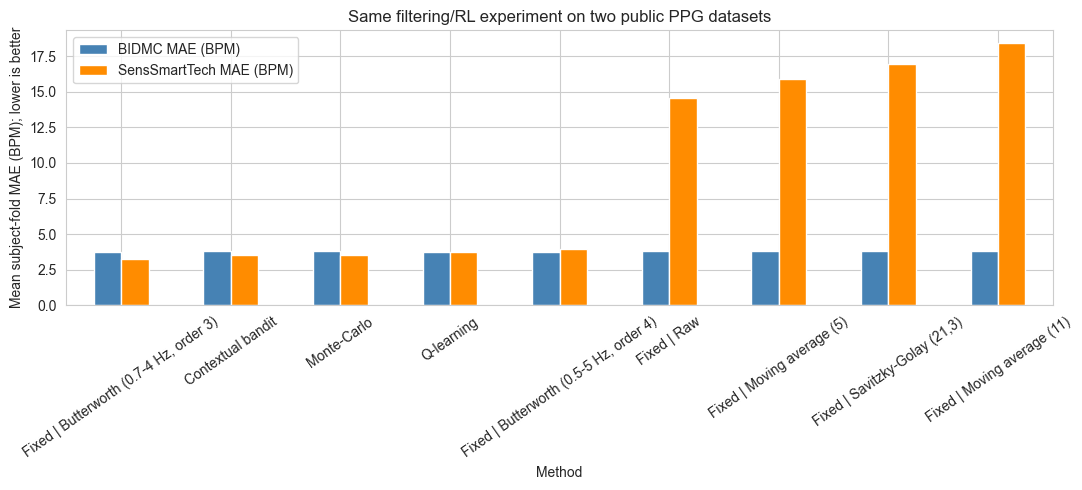

BIDMC best: Fixed | Butterworth (0.7-4 Hz, order 3) (3.743 BPM)
SensSmartTech best: Fixed | Butterworth (0.7-4 Hz, order 3) (3.221 BPM)
Interpretation: compare ranks and error magnitudes descriptively only; the datasets differ in population, sensor placement, sampling rate, and protocol.


In [48]:
# Fair cross-dataset reporting: mean over held-out subject folds for each dataset.
# Do not treat the two datasets as a pooled benchmark or apply cross-dataset p-values.
BIDMC_COMPARISON = (
    pd.read_csv('paper_outputs/fold_level_results.csv')
    .groupby('Method', as_index=False)
    .agg(**{'BIDMC MAE (BPM)': ('MAE (BPM)', 'mean'),
            'BIDMC RMSE (BPM)': ('RMSE (BPM)', 'mean'),
            'BIDMC failure (%)': ('Failed (%)', 'mean')})
)
SENSSMART_COMPARISON = S_SUMMARY.rename(columns={
    'Mean MAE (BPM)': 'SensSmartTech MAE (BPM)',
    'Mean RMSE (BPM)': 'SensSmartTech RMSE (BPM)',
    'Mean Failed (%)': 'SensSmartTech failure (%)'
})
DATASET_COMPARISON = BIDMC_COMPARISON.merge(
    SENSSMART_COMPARISON[['Method', 'SensSmartTech MAE (BPM)',
                           'SensSmartTech RMSE (BPM)', 'SensSmartTech failure (%)']],
    on='Method', how='inner'
).sort_values('SensSmartTech MAE (BPM)')
display(DATASET_COMPARISON.round(3))

common = DATASET_COMPARISON.set_index('Method')
fig, ax = plt.subplots(figsize=(11, 5))
common[['BIDMC MAE (BPM)', 'SensSmartTech MAE (BPM)']].plot.bar(ax=ax, color=['steelblue', 'darkorange'])
ax.set_ylabel('Mean subject-fold MAE (BPM); lower is better')
ax.set_title('Same filtering/RL experiment on two public PPG datasets')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

best_bidmc = BIDMC_COMPARISON.loc[BIDMC_COMPARISON['BIDMC MAE (BPM)'].idxmin()]
best_sens = SENSSMART_COMPARISON.loc[SENSSMART_COMPARISON['SensSmartTech MAE (BPM)'].idxmin()]
print(f"BIDMC best: {best_bidmc['Method']} ({best_bidmc['BIDMC MAE (BPM)']:.3f} BPM)")
print(f"SensSmartTech best: {best_sens['Method']} ({best_sens['SensSmartTech MAE (BPM)']:.3f} BPM)")
print('Interpretation: compare ranks and error magnitudes descriptively only; the datasets differ in population, sensor placement, sampling rate, and protocol.')


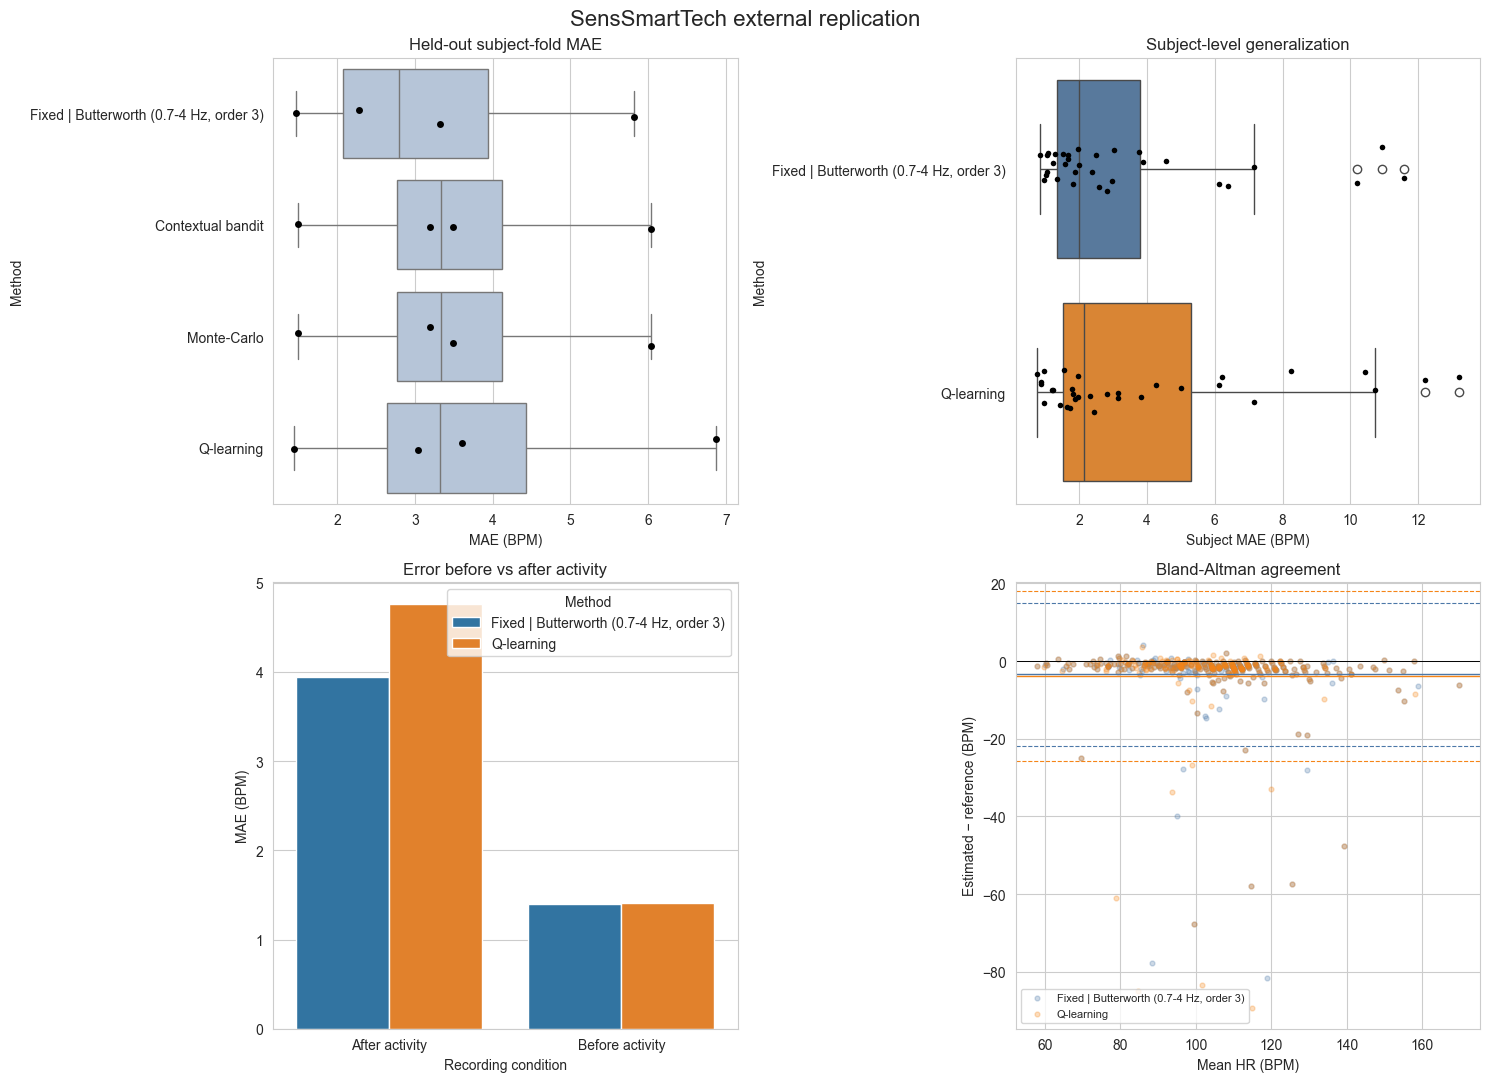

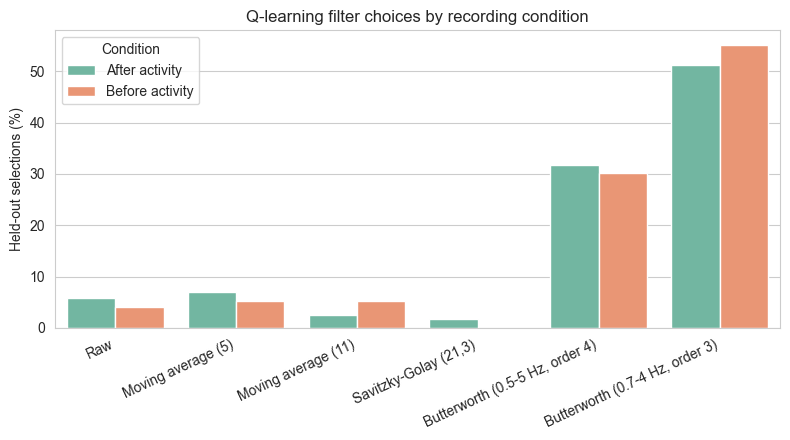

The best fixed method was Fixed | Butterworth (0.7-4 Hz, order 3) (mean MAE 3.221 BPM). Q-learning had 3.744 BPM mean MAE, a +0.523 BPM fold-mean difference. The p-values are exploratory because only four subject-grouped folds are available; report effect sizes and fold distributions, not a definitive significance claim.


,Best fixed method,Q-learning minus best-fixed MAE (BPM),Paired folds,Paired t-test p,Wilcoxon p
0,"Fixed | Butterworth (0.7-4 Hz, order 3)",0.5227,4,0.1206,0.25


,index,Method,activity,MAE (BPM),SD (BPM),N recordings,Condition
0,0,"Fixed | Butterworth (0.7-4 Hz, order 3)",A,3.947,8.564,242,After activity
1,1,"Fixed | Butterworth (0.7-4 Hz, order 3)",B,1.393,2.590,96,Before activity
2,2,Q-learning,A,4.764,10.734,242,After activity
3,3,Q-learning,B,1.404,2.601,96,Before activity


,activity,action,size,Action,Percentage,Condition
0,A,0,14,Raw,5.79,After activity
1,A,1,17,Moving average (5),7.02,After activity
2,A,2,6,Moving average (11),2.48,After activity
3,A,3,4,"Savitzky-Golay (21,3)",1.65,After activity
4,A,4,77,"Butterworth (0.5-5 Hz, order 4)",31.82,After activity
5,A,5,124,"Butterworth (0.7-4 Hz, order 3)",51.24,After activity
6,B,0,4,Raw,4.17,Before activity
7,B,1,5,Moving average (5),5.21,Before activity
8,B,2,5,Moving average (11),5.21,Before activity
9,B,4,29,"Butterworth (0.5-5 Hz, order 4)",30.21,Before activity


In [49]:
S_SUBJECT_MAE, S_ACTIVITY_MAE, S_ACTION_DISTRIBUTION, S_Q_VS_FIXED, S_PAPER_INTERPRETATION = build_senssmart_paper_outputs()


In [50]:
if 'S_SUMMARY' not in globals():
    raise RuntimeError('Run the SensSmartTech replication cell above first.')

print(f'Second dataset: SensSmartTech | recordings={len(S_DATA)} | subjects={S_DATA.subject.nunique()}')
display(S_SUMMARY.round(3))
display(DATASET_COMPARISON.round(3))


Second dataset: SensSmartTech | recordings=338 | subjects=32


,Method,Mean MAE (BPM),SD MAE (BPM),Mean RMSE (BPM),Mean Failed (%)
2,"Fixed | Butterworth (0.7-4 Hz, order 3)",3.221,1.887,6.860,0.000
0,Contextual bandit,3.551,1.876,8.128,0.392
7,Monte-Carlo,3.551,1.876,8.128,0.392
8,Q-learning,3.744,2.280,8.478,0.787
1,"Fixed | Butterworth (0.5-5 Hz, order 4)",3.930,2.630,8.766,0.291
5,Fixed | Raw,14.538,5.976,24.675,18.362
4,Fixed | Moving average (5),15.879,6.145,26.223,20.736
6,"Fixed | Savitzky-Golay (21,3)",16.966,6.027,27.238,21.622
3,Fixed | Moving average (11),18.404,5.815,28.578,24.585


,Method,BIDMC MAE (BPM),BIDMC RMSE (BPM),BIDMC failure (%),SensSmartTech MAE (BPM),SensSmartTech RMSE (BPM),SensSmartTech failure (%)
2,"Fixed | Butterworth (0.7-4 Hz, order 3)",3.743,7.533,0.000,3.221,6.860,0.000
0,Contextual bandit,3.787,7.752,0.066,3.551,8.128,0.392
7,Monte-Carlo,3.797,7.789,0.066,3.551,8.128,0.392
8,Q-learning,3.764,7.671,0.056,3.744,8.478,0.787
1,"Fixed | Butterworth (0.5-5 Hz, order 4)",3.763,7.653,0.015,3.930,8.766,0.291
5,Fixed | Raw,3.802,7.787,0.061,14.538,24.675,18.362
4,Fixed | Moving average (5),3.815,7.758,0.076,15.879,26.223,20.736
6,"Fixed | Savitzky-Golay (21,3)",3.778,7.807,0.122,16.966,27.238,21.622
3,Fixed | Moving average (11),3.809,7.840,0.107,18.404,28.578,24.585


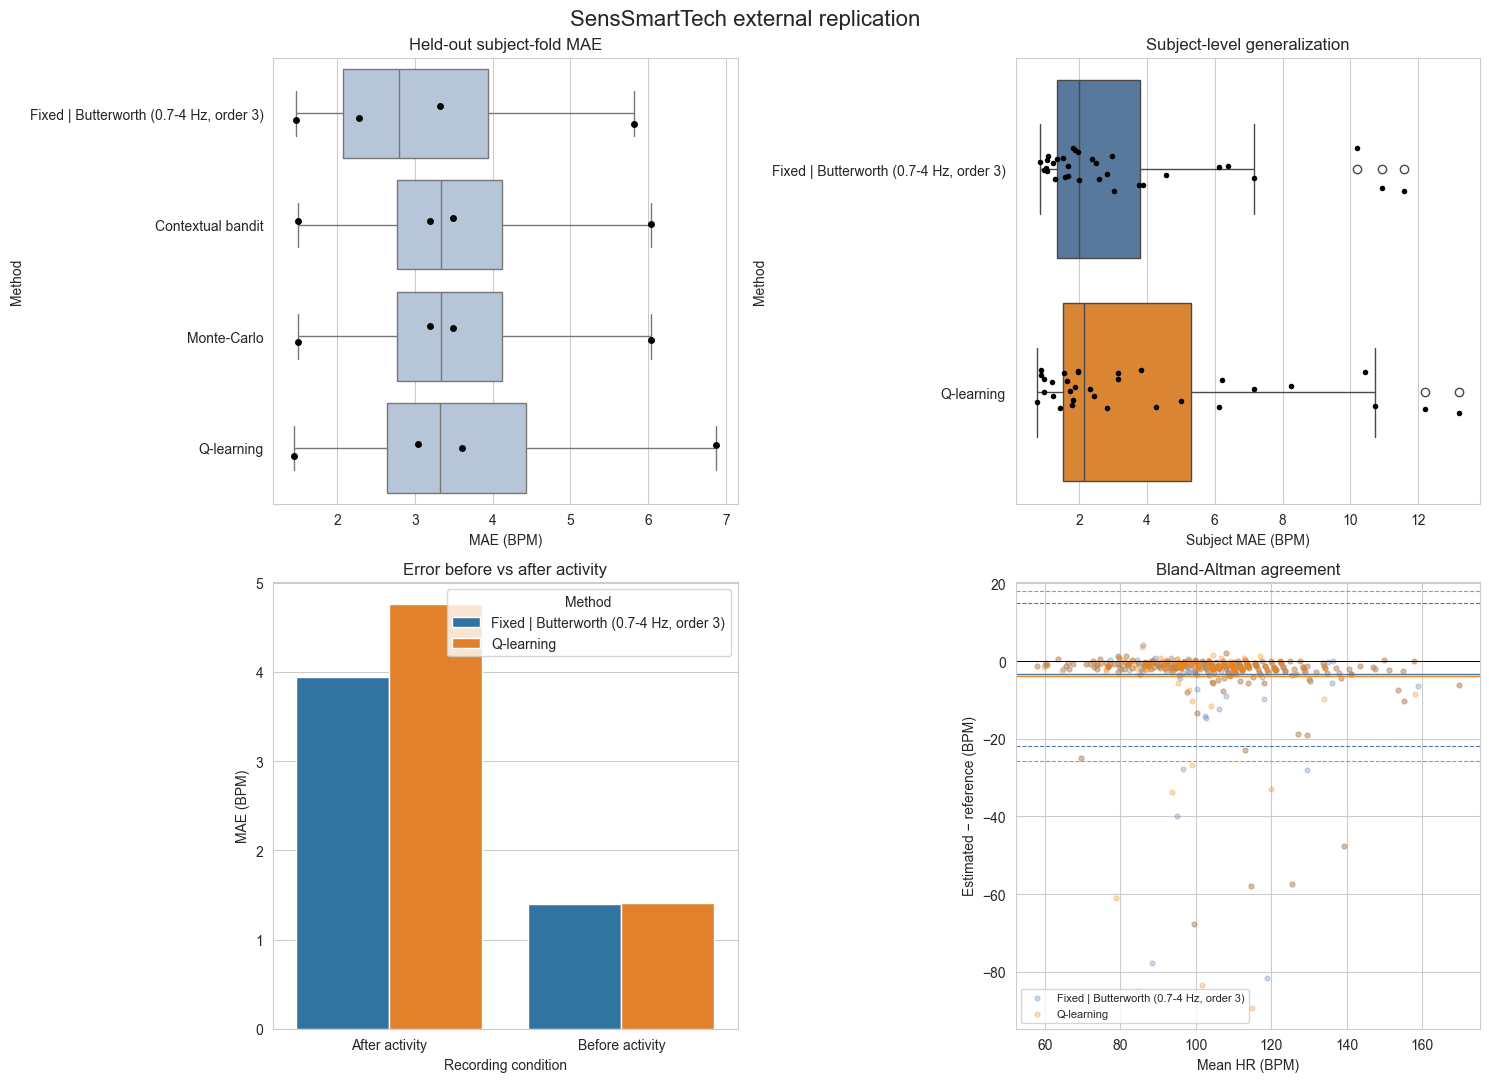

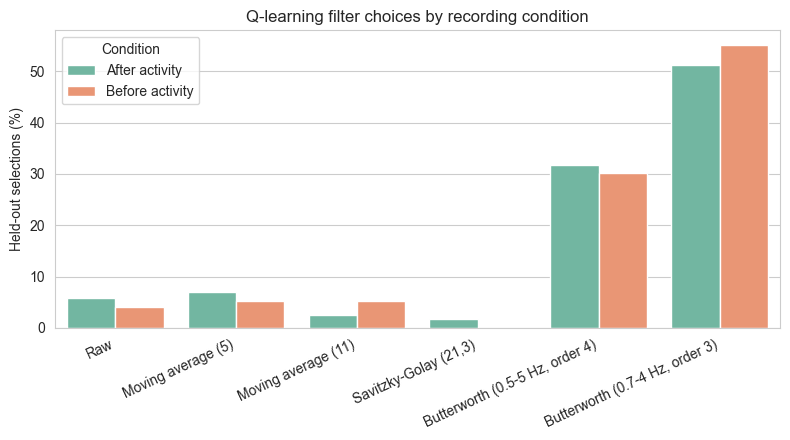

The best fixed method was Fixed | Butterworth (0.7-4 Hz, order 3) (mean MAE 3.221 BPM). Q-learning had 3.744 BPM mean MAE, a +0.523 BPM fold-mean difference. The p-values are exploratory because only four subject-grouped folds are available; report effect sizes and fold distributions, not a definitive significance claim.


,Best fixed method,Q-learning minus best-fixed MAE (BPM),Paired folds,Paired t-test p,Wilcoxon p
0,"Fixed | Butterworth (0.7-4 Hz, order 3)",0.5227,4,0.1206,0.25


,index,Method,activity,MAE (BPM),SD (BPM),N recordings,Condition
0,0,"Fixed | Butterworth (0.7-4 Hz, order 3)",A,3.947,8.564,242,After activity
1,1,"Fixed | Butterworth (0.7-4 Hz, order 3)",B,1.393,2.590,96,Before activity
2,2,Q-learning,A,4.764,10.734,242,After activity
3,3,Q-learning,B,1.404,2.601,96,Before activity


,activity,action,size,Action,Percentage,Condition
0,A,0,14,Raw,5.79,After activity
1,A,1,17,Moving average (5),7.02,After activity
2,A,2,6,Moving average (11),2.48,After activity
3,A,3,4,"Savitzky-Golay (21,3)",1.65,After activity
4,A,4,77,"Butterworth (0.5-5 Hz, order 4)",31.82,After activity
5,A,5,124,"Butterworth (0.7-4 Hz, order 3)",51.24,After activity
6,B,0,4,Raw,4.17,Before activity
7,B,1,5,Moving average (5),5.21,Before activity
8,B,2,5,Moving average (11),5.21,Before activity
9,B,4,29,"Butterworth (0.5-5 Hz, order 4)",30.21,Before activity


The best fixed method was Fixed | Butterworth (0.7-4 Hz, order 3) (mean MAE 3.221 BPM). Q-learning had 3.744 BPM mean MAE, a +0.523 BPM fold-mean difference. The p-values are exploratory because only four subject-grouped folds are available; report effect sizes and fold distributions, not a definitive significance claim.


In [51]:
# Paper figures and subject/activity/statistical analyses for the second dataset.
S_SUBJECT_MAE, S_ACTIVITY_MAE, S_ACTION_DISTRIBUTION, S_Q_VS_FIXED, S_PAPER_INTERPRETATION = build_senssmart_paper_outputs()
print(S_PAPER_INTERPRETATION)


In [52]:
# Cell A — public data download and experiment configuration
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from urllib.request import urlretrieve
from sklearn.model_selection import GroupKFold
from IPython.display import display
from scipy.signal import butter, sosfiltfilt, savgol_filter, find_peaks

S_ROOT = Path('public_datasets/senssmarttech')
S_CSV = S_ROOT / 'CSV'
S_URL = 'https://physionet.org/files/senssmarttech/1.0.0'
S_FS, S_SEEDS, S_EPOCHS = 100, [11, 22, 33], 40
S_ACTIONS = {0: 'Raw', 1: 'Moving average (5)', 2: 'Moving average (11)',
             3: 'Savitzky-Golay (21,3)', 4: 'Butterworth (0.5-5 Hz, order 4)',
             5: 'Butterworth (0.7-4 Hz, order 3)'}

S_ROOT.mkdir(parents=True, exist_ok=True); S_CSV.mkdir(exist_ok=True)
demographics_path = S_ROOT / 'Demographics.csv'
if not demographics_path.exists():
    urlretrieve(f'{S_URL}/Demographics.csv', demographics_path)
S_META = pd.read_csv(demographics_path, skiprows=1).iloc[:, :14]
S_META = S_META[S_META['PPG'].notna()].copy()

def download_ppg_file(name):
    destination = S_CSV / f'{name}.csv'
    if not destination.exists():
        urlretrieve(f'{S_URL}/CSV/{name}.csv', destination)

with ThreadPoolExecutor(max_workers=12) as pool:
    list(pool.map(download_ppg_file, S_META['PPG'].astype(str)))
print(f'Download ready: {len(S_META)} recordings from {S_META["Subject number"].nunique()} subjects')


Download ready: 338 recordings from 32 subjects


In [53]:
# Cell B — PPG preprocessing, six filter actions, HR estimator, and quality-state features
def s_apply_filter(x, action):
    if action == 0: return x.copy()
    if action == 1: return np.convolve(x, np.ones(5)/5, mode='same')
    if action == 2: return np.convolve(x, np.ones(11)/11, mode='same')
    if action == 3: return savgol_filter(x, 21, 3)
    band, order = ([0.5, 5.0], 4) if action == 4 else ([0.7, 4.0], 3)
    sos = butter(order, band, btype='bandpass', fs=S_FS, output='sos')
    return sosfiltfilt(sos, x)

def s_estimate_hr(x):
    z = (x - np.mean(x)) / (np.std(x) + 1e-8)
    peaks, _ = find_peaks(z, distance=int(0.25*S_FS), prominence=0.35)
    if len(peaks) < 2: return np.nan
    hr = 60 / np.median(np.diff(peaks) / S_FS)
    return hr if 35 <= hr <= 220 else np.nan

def s_quality_features(x):
    z = (x - x.mean()) / (x.std() + 1e-8)
    noise = np.std(z - savgol_filter(z, 31, 3)) / (np.std(z) + 1e-8)
    hist, _ = np.histogram(z, bins=32, density=True); p = hist[hist > 0]; p /= p.sum()
    peaks, properties = find_peaks(z, distance=int(0.25*S_FS), prominence=0.35)
    peak_quality = np.median(properties['prominences']) if len(peaks) else 0.0
    return [1-noise, -np.sum(p*np.log(p)), peak_quality]


In [ ]:

S_ROWS = []
for _, row in S_META.iterrows():
    x = pd.read_csv(S_CSV / f"{row['PPG']}.csv").iloc[:, 1].to_numpy(float)
    if len(x) >= 500 and np.isfinite(x).all():
        S_ROWS.append({'record': row['PPG'], 'subject': int(row['Subject number']),
                       'activity': row['Before (B)  / after (A) activity'],
                       'reference_hr': float(row['Median heart rate (bpm)']),
                       'signal': x, 'features': s_quality_features(x)})
S_DATA = pd.DataFrame(S_ROWS)
S_REF = S_DATA.reference_hr.to_numpy(float); S_GROUPS = S_DATA.subject.to_numpy()
S_FEATURES = np.vstack(S_DATA.features.to_numpy())
S_ESTIMATES = np.array([[s_estimate_hr(s_apply_filter(x, action)) for action in S_ACTIONS] for x in S_DATA.signal])
S_ERRORS = np.where(np.isfinite(S_ESTIMATES), np.minimum(abs(S_ESTIMATES-S_REF[:, None]), 50), 50)

def s_train_policy(train_indices, states, algorithm, seed):
    rng = np.random.default_rng(seed); q = np.zeros((27, len(S_ACTIONS))); visits = np.zeros_like(q, dtype=int); epsilon = 1.0
    for _ in range(S_EPOCHS):
        for index in rng.permutation(train_indices):
            state = states[index]
            action = rng.integers(len(S_ACTIONS)) if rng.random() < epsilon else rng.choice(np.flatnonzero(q[state] == q[state].max()))
            visits[state, action] += 1
            alpha = 1/visits[state, action] if algorithm != 'q' else 0.10/np.sqrt(visits[state, action])
            q[state, action] += alpha * (-S_ERRORS[index, action] - q[state, action])
        epsilon = max(0.05, epsilon*0.97)
    return q


In [55]:
# Cell D — 4-fold grouped evaluation and result tables
S_RESULT_ROWS, S_PRED_ROWS = [], []
for fold, (train, test) in enumerate(GroupKFold(n_splits=4).split(S_FEATURES, groups=S_GROUPS), 1):
    edges = np.quantile(S_FEATURES[train], [0.33, 0.66], axis=0)
    S_STATES = np.clip(np.digitize(S_FEATURES[:,0], edges[:,0])*9 + np.digitize(S_FEATURES[:,1], edges[:,1])*3 + np.digitize(S_FEATURES[:,2], edges[:,2]), 0, 26)
    for action, name in S_ACTIONS.items():
        pred = S_ESTIMATES[test, action]; error = np.where(np.isfinite(pred), np.minimum(abs(pred-S_REF[test]),50),50)
        S_RESULT_ROWS.append({'Fold':fold, 'Method':'Fixed | '+name, 'Seed':0, 'MAE (BPM)':error.mean(), 'RMSE (BPM)':np.sqrt(np.mean(error**2)), 'Failed (%)':100*(~np.isfinite(pred)).mean()})
    for algorithm, label in [('mc','Monte-Carlo'), ('q','Q-learning'), ('bandit','Contextual bandit')]:
        for seed in S_SEEDS:
            policy = s_train_policy(train, S_STATES, algorithm, seed); chosen = np.argmax(policy[S_STATES[test]], axis=1); pred = S_ESTIMATES[test, chosen]
            error = np.where(np.isfinite(pred), np.minimum(abs(pred-S_REF[test]),50),50)
            S_RESULT_ROWS.append({'Fold':fold, 'Method':label, 'Seed':seed, 'MAE (BPM)':error.mean(), 'RMSE (BPM)':np.sqrt(np.mean(error**2)), 'Failed (%)':100*(~np.isfinite(pred)).mean()})
S_RESULTS = pd.DataFrame(S_RESULT_ROWS)
S_FOLD_RESULTS = S_RESULTS.groupby(['Fold','Method'], as_index=False)[['MAE (BPM)','RMSE (BPM)','Failed (%)']].mean()
S_SUMMARY = S_FOLD_RESULTS.groupby('Method', as_index=False).agg(**{'Mean MAE (BPM)':('MAE (BPM)','mean'),'SD MAE (BPM)':('MAE (BPM)','std'),'Mean RMSE (BPM)':('RMSE (BPM)','mean'),'Mean Failed (%)':('Failed (%)','mean')}).sort_values('Mean MAE (BPM)')
display(S_SUMMARY.round(3))
S_RESULTS.to_csv('paper_outputs/senssmarttech_seed_results.csv', index=False)
S_FOLD_RESULTS.to_csv('paper_outputs/senssmarttech_fold_results.csv', index=False)
S_SUMMARY.to_csv('paper_outputs/senssmarttech_summary.csv', index=False)


,Method,Mean MAE (BPM),SD MAE (BPM),Mean RMSE (BPM),Mean Failed (%)
2,"Fixed | Butterworth (0.7-4 Hz, order 3)",3.221,1.887,6.860,0.000
0,Contextual bandit,3.551,1.876,8.128,0.392
7,Monte-Carlo,3.551,1.876,8.128,0.392
8,Q-learning,3.744,2.280,8.478,0.787
1,"Fixed | Butterworth (0.5-5 Hz, order 4)",3.930,2.630,8.766,0.291
5,Fixed | Raw,14.538,5.976,24.675,18.362
4,Fixed | Moving average (5),15.879,6.145,26.223,20.736
6,"Fixed | Savitzky-Golay (21,3)",16.966,6.027,27.238,21.622
3,Fixed | Moving average (11),18.404,5.815,28.578,24.585
